# Hero FinCorp: A Comprehensive Data-Driven Analysis

## Importing Libraries and Loading Datasets

In [277]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [278]:
#Importing Datasets
customers = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\customers.csv")
loans = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\loans.csv")
applications = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\applications.csv")
transactions = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\transactions.csv")
defaults = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\defaults.csv")
branches = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\branches.csv")

C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\3002152306.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\Datasets (1) (1)\applications.csv")


## Analysis Tasks 1 : Data Quality and Preparation
1. Validate and clean the datasets.
2. Check for missing values, duplicate entries and inconsistent data.
3. Standardize date formats and remove irrelevant columns.
4. Handle outliers in numeric columns like Loan_Amount, Interest_Rate and Default_Amount

In [279]:
#STANDARDIZE COLUMN NAMES

def standardize_columns(df):
    df.columns = (
        df.columns.str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace(r"\s+", "_", regex=True)
    )
    return df

customers = standardize_columns(customers)
loans = standardize_columns(loans)
applications = standardize_columns(applications)
transactions = standardize_columns(transactions)
branches = standardize_columns(branches)
defaults = standardize_columns(defaults)

print("Column Names Standardized!")

Column Names Standardized!


In [280]:
#CHECK MISSING VALUES

def missing_values_report(df, name):
    print(f"\nMissing Values Report: {name}")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))

missing_values_report(customers, "Customers")
missing_values_report(loans, "Loans")
missing_values_report(applications, "Applications")
missing_values_report(transactions, "Transactions")
missing_values_report(branches, "Branches")
missing_values_report(defaults, "Defaults")


Missing Values Report: Customers
Series([], dtype: int64)

Missing Values Report: Loans
Collateral_Details    30194
dtype: int64

Missing Values Report: Applications
Rejection_Reason    70000
Loan_ID             12600
Approval_Date       12600
dtype: int64

Missing Values Report: Transactions
Series([], dtype: int64)

Missing Values Report: Branches
Series([], dtype: int64)

Missing Values Report: Defaults
Recovery_Status    2985
dtype: int64


In [334]:
#REMOVE DUPLICATES

def remove_duplicates(df, name):
    before = df.shape[0]
    df.drop_duplicates(inplace=True)
    after = df.shape[0]
    print(f"{name}: Removed {before - after} duplicate rows")
    return df

customers = remove_duplicates(customers, "Customers")
loans = remove_duplicates(loans, "Loans")
applications = remove_duplicates(applications, "Applications")
transactions = remove_duplicates(transactions, "Transactions")
branches = remove_duplicates(branches, "Branches")
defaults = remove_duplicates(defaults, "Defaults")

Customers: Removed 0 duplicate rows
Loans: Removed 0 duplicate rows
Applications: Removed 0 duplicate rows
Transactions: Removed 0 duplicate rows
Branches: Removed 0 duplicate rows
Defaults: Removed 0 duplicate rows


In [282]:
#HANDLE INCONSISTENT DATA

# Standardize categorical columns
if "Employment_Status" in customers.columns:
    customers["Employment_Status"] = customers["Employment_Status"].astype(str).str.strip().str.title()

if "Approval_Status" in applications.columns:
    applications["Approval_Status"] = applications["Approval_Status"].astype(str).str.strip().str.title()

if "Payment_Type" in transactions.columns:
    transactions["Payment_Type"] = transactions["Payment_Type"].astype(str).str.strip().str.title()

print("Categorical Columns Standardized!")

# Fix rejection reason consistency
if "Approval_Status" in applications.columns and "Rejection_Reason" in applications.columns:
    applications["Rejection_Reason"] = applications["Rejection_Reason"].fillna("Not_Rejected")
    approved_mask = applications["Approval_Status"].str.lower() == "approved"
    applications.loc[approved_mask, "Rejection_Reason"] = "Not_Rejected"

# Fill missing collateral details in loans
if "Collateral_Details" in loans.columns:
    loans["Collateral_Details"] = loans["Collateral_Details"].fillna("None")

# Fill missing recovery status in defaults
if "Recovery_Status" in defaults.columns:
    defaults["Recovery_Status"] = defaults["Recovery_Status"].fillna("Unknown")

print("Inconsistencies Fixed!")

Categorical Columns Standardized!
Inconsistencies Fixed!


In [283]:
#STANDARDIZE DATE FORMATS

def standardize_dates(df, name):
    for col in df.columns:
        if "Date" in col or col.lower().endswith("_date"):
            df[col] = pd.to_datetime(df[col], errors="coerce")
    print(f"{name}: Date formats standardized")
    return df

customers = standardize_dates(customers, "Customers")
loans = standardize_dates(loans, "Loans")
applications = standardize_dates(applications, "Applications")
transactions = standardize_dates(transactions, "Transactions")
branches = standardize_dates(branches, "Branches")
defaults = standardize_dates(defaults, "Defaults")

Customers: Date formats standardized
Loans: Date formats standardized
Applications: Date formats standardized
Transactions: Date formats standardized
Branches: Date formats standardized
Defaults: Date formats standardized


In [284]:
#REMOVE IRRELEVANT COLUMNS

irrelevant_columns_customers = ["Full_Name"]
irrelevant_columns_transactions = []

customers.drop(columns=[col for col in irrelevant_columns_customers if col in customers.columns], inplace=True)
transactions.drop(columns=[col for col in irrelevant_columns_transactions if col in transactions.columns], inplace=True)

print("Irrelevant Columns Removed!")

Irrelevant Columns Removed!


In [285]:
#HANDLE OUTLIERS (WINSORIZATION)

def winsorize(df, col, lower_q=0.01, upper_q=0.99):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower, upper)
        print(f"Outliers handled for {col}")
    return df

loans = winsorize(loans, "Loan_Amount")
loans = winsorize(loans, "Interest_Rate")
defaults = winsorize(defaults, "Default_Amount")

print("Outlier Treatment Completed!")

Outliers handled for Loan_Amount
Outliers handled for Interest_Rate
Outliers handled for Default_Amount
Outlier Treatment Completed!


In [286]:
#FINAL VALIDATION REPORT

def final_report(df, name):
    print(f"\nFinal Report: {name}")
    print("Shape:", df.shape)
    print("Missing Values:", df.isnull().sum().sum())

final_report(customers, "Customers")
final_report(loans, "Loans")
final_report(applications, "Applications")
final_report(transactions, "Transactions")
final_report(branches, "Branches")
final_report(defaults, "Defaults")


Final Report: Customers
Shape: (70000, 13)
Missing Values: 0

Final Report: Loans
Shape: (90000, 12)
Missing Values: 0

Final Report: Applications
Shape: (82600, 10)
Missing Values: 25200

Final Report: Transactions
Shape: (495000, 9)
Missing Values: 0

Final Report: Branches
Shape: (50, 9)
Missing Values: 0

Final Report: Defaults
Shape: (9000, 9)
Missing Values: 0


## Analysis Tasks 2 : Descriptive Analysis

Summarize and visualize key metrics:
1. Distribution of Loan_Amount, EMI_Amount and Credit_Score.
2. Regional trends in loan disbursement and defaults.
3. Monthly trends in loan approvals and disbursements.

In [287]:
#EMI CALCULATION

def calculate_emi(P, annual_rate, term_months):
    r = annual_rate / (12 * 100)
    n = term_months
    if r == 0:
        return P / n
    emi = P * r * (1+r)**n / ((1+r)**n - 1)
    return emi

if "EMI_Amount" not in loans.columns:
    loans["EMI_Amount"] = loans.apply(
        lambda x: calculate_emi(x["Loan_Amount"], x["Interest_Rate"], x["Loan_Term"]), axis=1
    )
    print("EMI_Amount calculated and added!")

In [288]:
#MERGE DATASETS FOR ANALYSIS

df = loans.merge(customers, on="Customer_ID", how="left")

# Add Default Flag
df["Default_Flag"] = df["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

print("Merged dataset created!")

Merged dataset created!


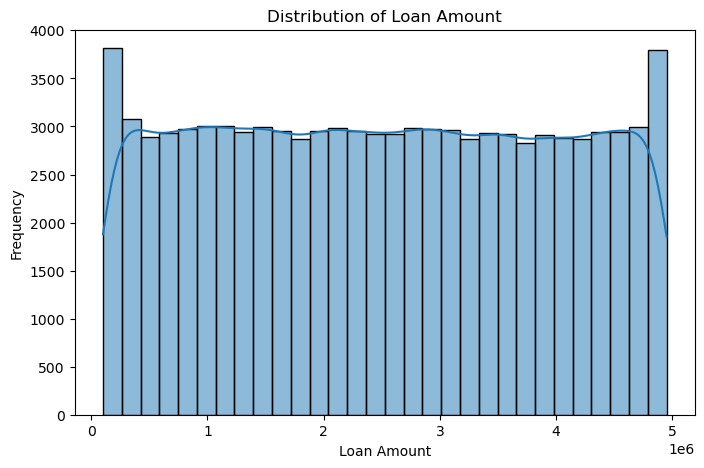

In [289]:
#Loan Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Loan_Amount"], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

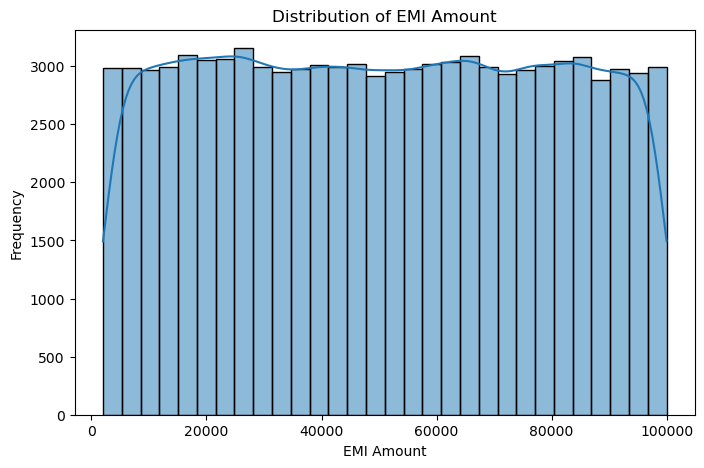

In [290]:
#EMI Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["EMI_Amount"], bins=30, kde=True)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()

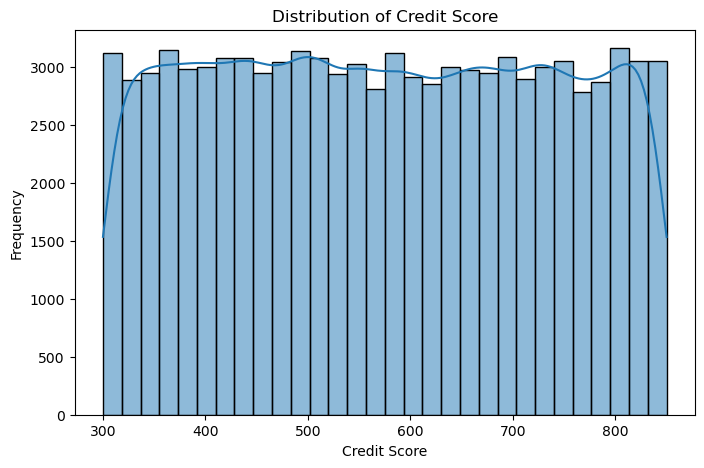

In [291]:
#Credit Score Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Credit_Score"], bins=30, kde=True)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

In [292]:
# Summary
print("\n========== SUMMARY STATISTICS ==========")
print(df[["Loan_Amount", "EMI_Amount", "Credit_Score"]].describe())
print("=======================================\n")


========== SUMMARY STATISTICS ==========
        Loan_Amount     EMI_Amount  Credit_Score
count  9.000000e+04   90000.000000  90000.000000
mean   2.516279e+06   50874.181444    574.118878
std    1.428448e+06   28274.305704    159.187813
min    1.003300e+05    2001.000000    300.000000
25%    1.275705e+06   26229.750000    436.000000
50%    2.510076e+06   50861.000000    573.000000
75%    3.751702e+06   75431.250000    713.000000
max    4.951026e+06  100000.000000    850.000000



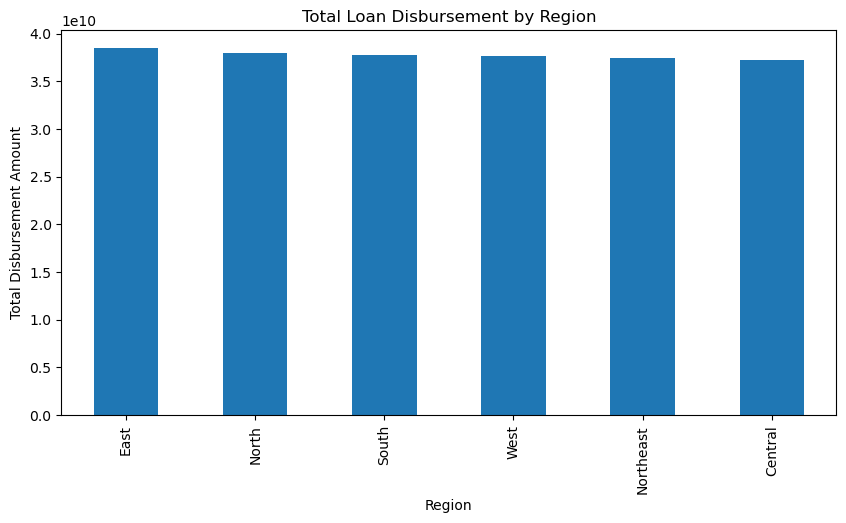

In [293]:
#Regional Loan Disbursement
region_disbursement = df.groupby("Region")["Loan_Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
region_disbursement.plot(kind="bar")
plt.title("Total Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursement Amount")
plt.show()

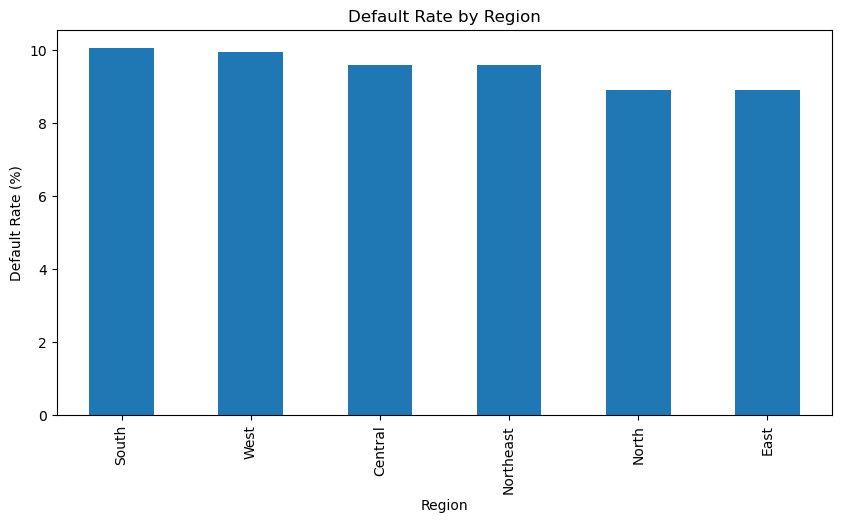

In [294]:
# Regional Default Rate
region_default_rate = df.groupby("Region")["Default_Flag"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))
region_default_rate.plot(kind="bar")
plt.title("Default Rate by Region")
plt.xlabel("Region")
plt.ylabel("Default Rate (%)")
plt.show()

In [295]:
print("\n========== REGIONAL INSIGHTS ==========")
print("\nLoan Disbursement by Region:\n", region_disbursement)
print("\nDefault Rate by Region (%):\n", region_default_rate)
print("======================================\n")


========== REGIONAL INSIGHTS ==========

Loan Disbursement by Region:
 Region
East         3.843841e+10
North        3.796414e+10
South        3.774070e+10
West         3.760005e+10
Northeast    3.747781e+10
Central      3.724395e+10
Name: Loan_Amount, dtype: float64

Default Rate by Region (%):
 Region
South        10.040805
West          9.932219
Central       9.583137
Northeast     9.582441
North         8.908982
East          8.899190
Name: Default_Flag, dtype: float64



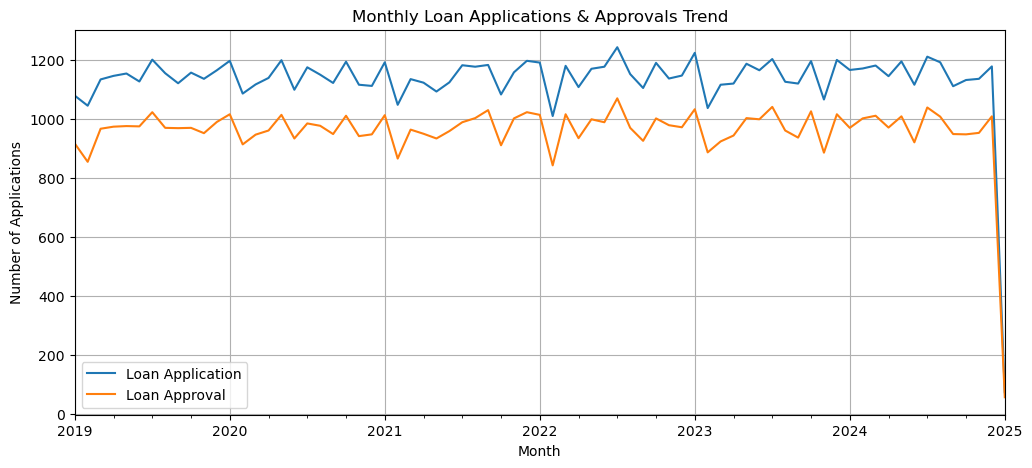

In [296]:
#Monthly Loan Applications & Approvals
applications["Month"] = applications["Application_Date"].dt.to_period("M")

monthly_apps = applications.groupby("Month")["Application_ID"].count()

if "Approval_Status" in applications.columns:
    approved_apps = applications[applications["Approval_Status"].str.lower() == "approved"]
    monthly_approved = approved_apps.groupby("Month")["Application_ID"].count()

plt.figure(figsize=(12,5))
monthly_apps.plot(label = "Loan Application")
monthly_approved.plot(label = "Loan Approval")
plt.title("Monthly Loan Applications & Approvals Trend")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.legend()
plt.show()


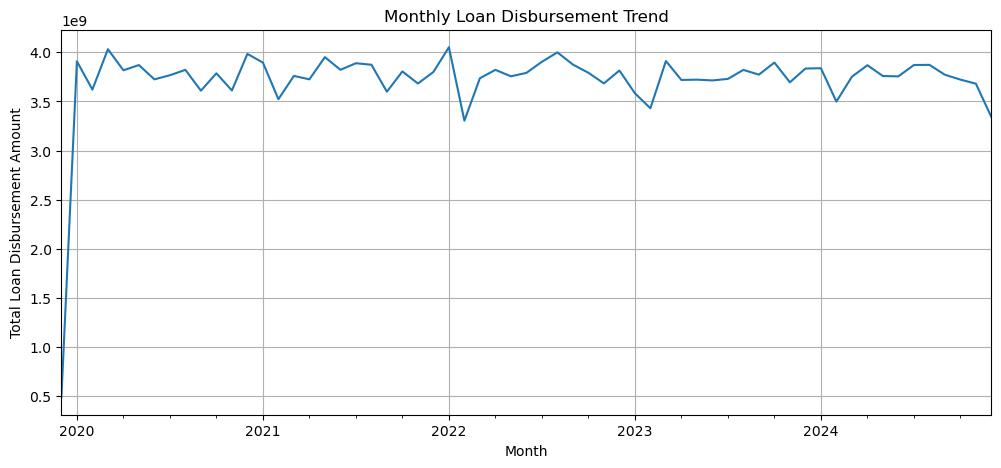


========== MONTHLY DISBURSEMENT ==========
Disbursement_Month
2019-12    4.912983e+08
2020-01    3.908444e+09
2020-02    3.620951e+09
2020-03    4.031729e+09
2020-04    3.817062e+09
2020-05    3.870555e+09
2020-06    3.725124e+09
2020-07    3.766806e+09
2020-08    3.821700e+09
2020-09    3.609673e+09
Freq: M, Name: Loan_Amount, dtype: float64



In [297]:
#Monthly Loan Disbursement Trend

if "Disbursal_Date" in loans.columns:
    loans["Disbursement_Month"] = loans["Disbursal_Date"].dt.to_period("M")
    monthly_disbursement = loans.groupby("Disbursement_Month")["Loan_Amount"].sum()

    plt.figure(figsize=(12,5))
    monthly_disbursement.plot()
    plt.title("Monthly Loan Disbursement Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Loan Disbursement Amount")
    plt.grid(True)
    plt.show()

    print("\n========== MONTHLY DISBURSEMENT ==========")
    print(monthly_disbursement.head(10))
    print("=========================================\n")

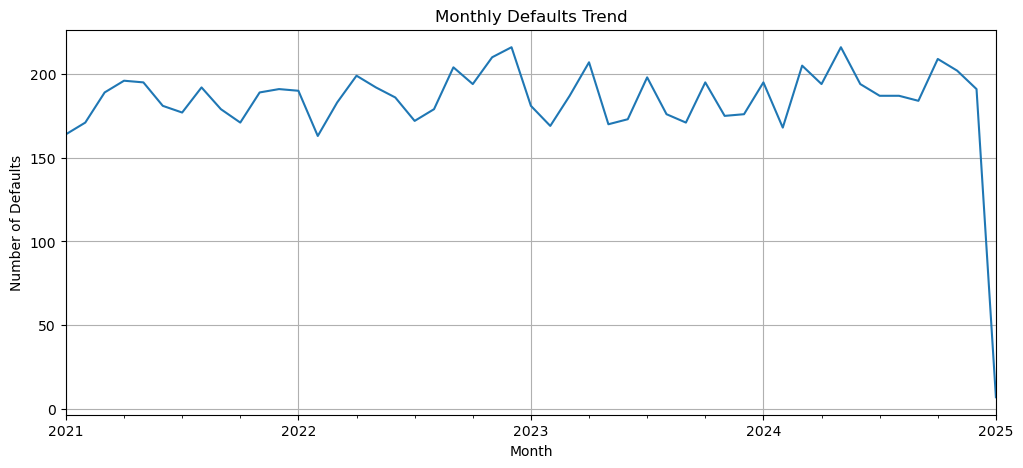


========== MONTHLY DEFAULTS ==========
Month
2021-01    164
2021-02    171
2021-03    189
2021-04    196
2021-05    195
2021-06    181
2021-07    177
2021-08    192
2021-09    179
2021-10    171
Freq: M, Name: Default_ID, dtype: int64



In [298]:
#Monthly Defaults Trend

defaults["Month"] = defaults["Default_Date"].dt.to_period("M")
monthly_defaults = defaults.groupby("Month")["Default_ID"].count()

plt.figure(figsize=(12,5))
monthly_defaults.plot()
plt.title("Monthly Defaults Trend")
plt.xlabel("Month")
plt.ylabel("Number of Defaults")
plt.grid(True)
plt.show()

print("\n========== MONTHLY DEFAULTS ==========")
print(monthly_defaults.head(10))
print("=====================================\n")

## Analysis Tasks 3 : Default Risk Analysis

1. Correlation Between Loan Attributes and Defaults: Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score and Default_Flag.
2. Pairwise Correlation Analysis: Creating a heatmap to visualize the correlations between key variables as EMI_Amount, Overdue_Amount and Default_Amount.


======================== CORRELATION MATRIX ==========================
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000118     -0.003311
Interest_Rate    -0.003201       1.000000      0.002449     -0.003736
Credit_Score      0.000118       0.002449      1.000000     -0.001580
Default_Flag     -0.003311      -0.003736     -0.001580      1.000000



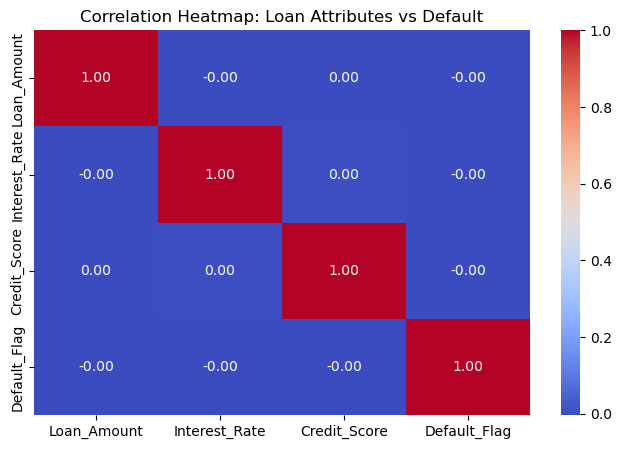

In [299]:
#Correlation Between Loan Attributes and Defaults

corr_data = df[["Loan_Amount", "Interest_Rate", "Credit_Score", "Default_Flag"]]

correlation_matrix = corr_data.corr()

print("\n======================== CORRELATION MATRIX ==========================")
print(correlation_matrix)
print("======================================================================\n")

plt.figure(figsize=(8,5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Loan Attributes vs Default")
plt.show()


================== PAIRWISE CORRELATION MATRIX ==========
                EMI_Amount  Overdue_Amount  Default_Amount
EMI_Amount        1.000000        0.000386        0.003068
Overdue_Amount    0.000386        1.000000       -0.001530
Default_Amount    0.003068       -0.001530        1.000000



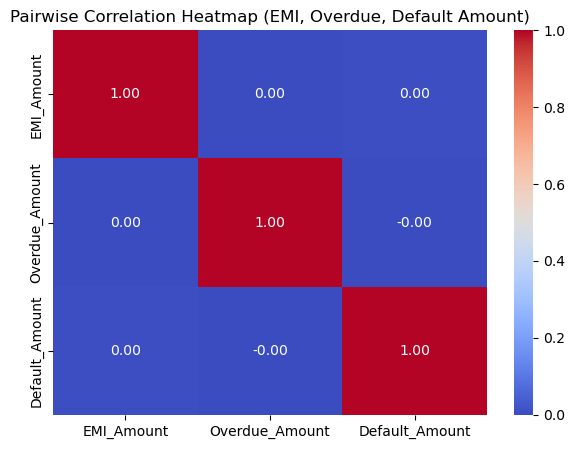

In [300]:
#Pairwise Correlation Analysis

df = loans.merge(defaults[["Loan_ID", "Default_Amount"]], on="Loan_ID", how="left")

df["Default_Amount"] = df["Default_Amount"].fillna(0)

corr_data = df[["EMI_Amount", "Overdue_Amount", "Default_Amount"]]

correlation_matrix = corr_data.corr()

print("\n================== PAIRWISE CORRELATION MATRIX ==========")
print(correlation_matrix)
print("=========================================================\n")

plt.figure(figsize=(7,5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pairwise Correlation Heatmap (EMI, Overdue, Default Amount)")
plt.show()

## Analysis Task 4 : Branch and Regional Performance

1. Rank branches by loan disbursement volume, Process time efficiency, Default and recovery rates
2. Compare branch performance across regions.

In [301]:
#Rank branches by loan disbursement volume

top_disbursement = branches.nlargest(10, 'Loan_Disbursement_Amount')[['Branch_ID', 'Region', 'Loan_Disbursement_Amount', 'Total_Active_Loans']]
print(top_disbursement)

print("\nBranches with Highest Delinquency Rates:")
branches['Delinquency_Rate'] = (branches['Delinquent_Loans'] / branches['Total_Active_Loans'] * 100)
high_delinquency = branches.nlargest(10, 'Delinquency_Rate')[['Branch_ID', 'Region', 'Delinquency_Rate', 'Delinquent_Loans']]
print(high_delinquency)

   Branch_ID   Region  Loan_Disbursement_Amount  Total_Active_Loans
35      B036     East                 499562869                 949
13      B014    North                 482327541                 439
11      B012     West                 465469874                1714
47      B048  Central                 464419943                1601
34      B035  Central                 449109596                 618
42      B043     East                 447832443                 872
2       B003  Central                 445787808                 122
49      B050    North                 442594434                 323
9       B010     West                 435407779                1810
36      B037    North                 420746720                1585

Branches with Highest Delinquency Rates:
   Branch_ID     Region  Delinquency_Rate  Delinquent_Loans
2       B003    Central        137.704918               168
31      B032  Northeast         68.127490               171
7       B008    Central       

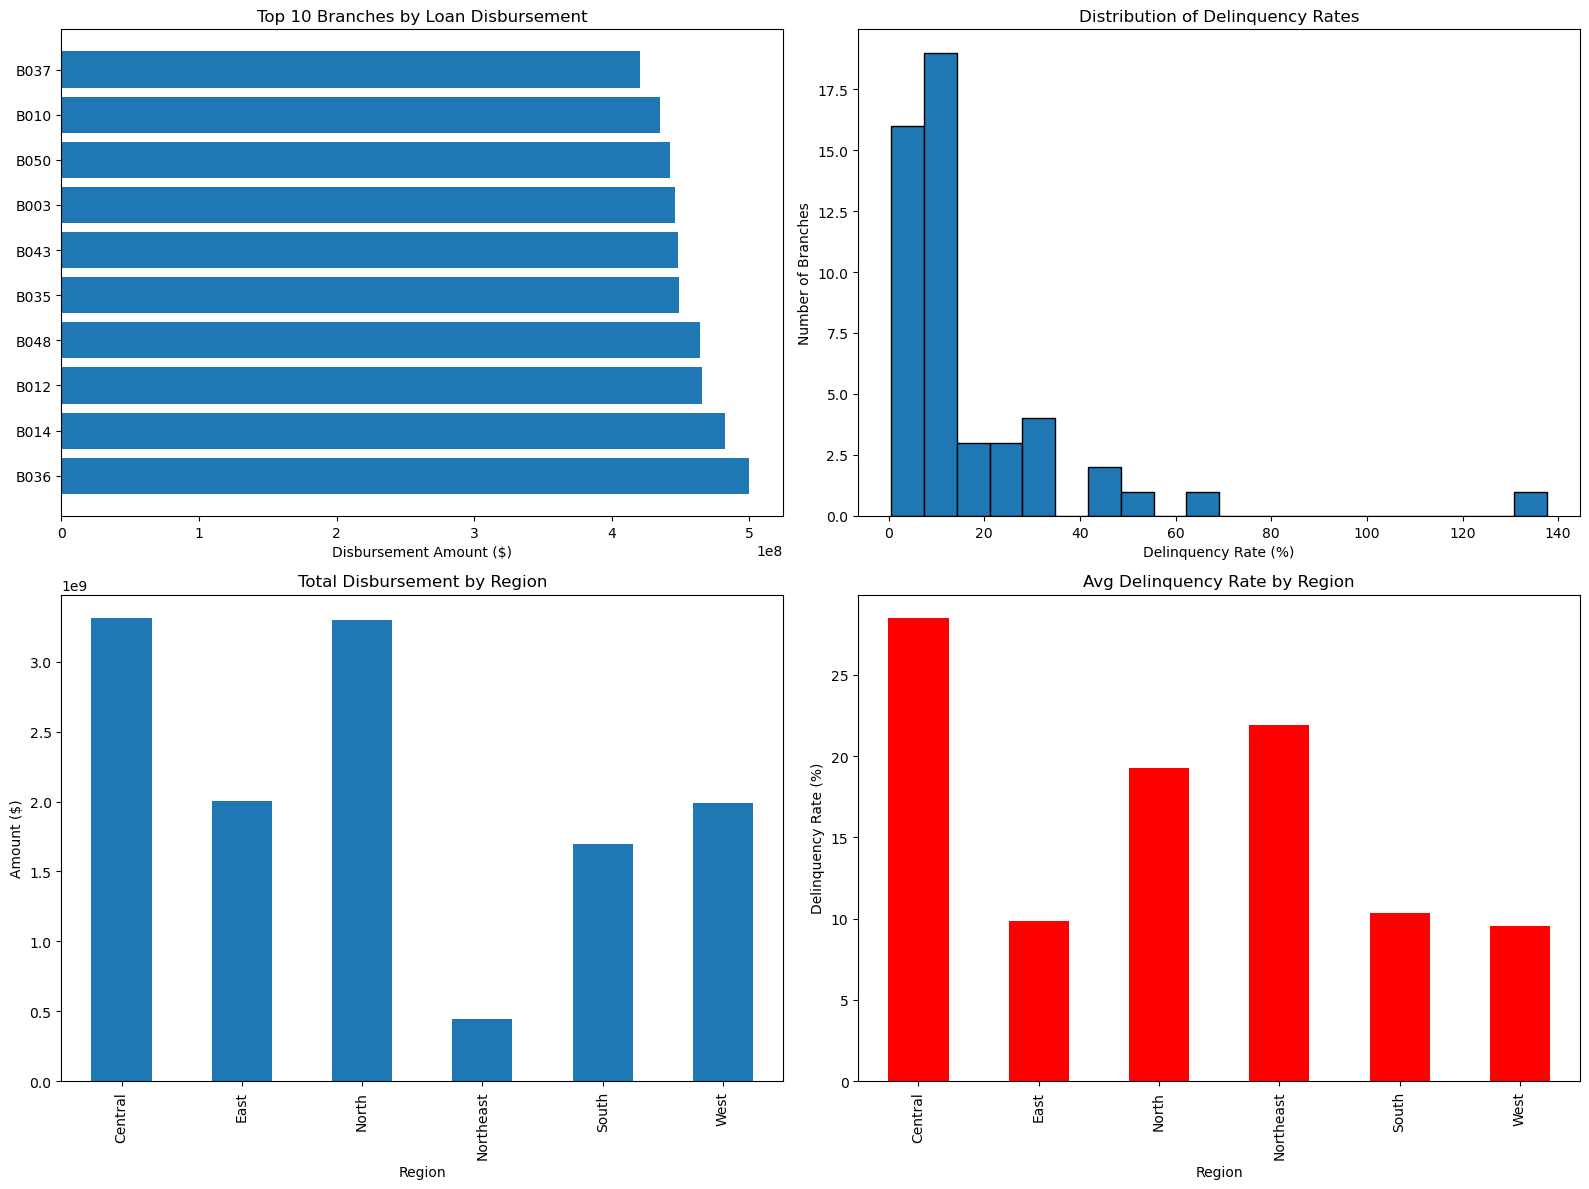

In [302]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 branches by disbursement
top_10_disburse = branches.nlargest(10, 'Loan_Disbursement_Amount')
axes[0, 0].barh(range(len(top_10_disburse)), top_10_disburse['Loan_Disbursement_Amount'])
axes[0, 0].set_yticks(range(len(top_10_disburse)))
axes[0, 0].set_yticklabels(top_10_disburse['Branch_ID'])
axes[0, 0].set_title('Top 10 Branches by Loan Disbursement')
axes[0, 0].set_xlabel('Disbursement Amount ($)')

# Distribution of delinquency rates
axes[0, 1].hist(branches['Delinquency_Rate'], bins=20, edgecolor='black')
axes[0, 1].set_title('Distribution of Delinquency Rates')
axes[0, 1].set_xlabel('Delinquency Rate (%)')
axes[0, 1].set_ylabel('Number of Branches')

# Regional comparison
if 'Region' in branches.columns:
    regional_perf = branches.groupby('Region').agg({
        'Loan_Disbursement_Amount': 'sum',
        'Delinquency_Rate': 'mean'
    })
    regional_perf['Loan_Disbursement_Amount'].plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_title('Total Disbursement by Region')
    axes[1, 0].set_ylabel('Amount ($)')
    
    regional_perf['Delinquency_Rate'].plot(kind='bar', ax=axes[1, 1], color='red')
    axes[1, 1].set_title('Avg Delinquency Rate by Region')
    axes[1, 1].set_ylabel('Delinquency Rate (%)')

plt.tight_layout()
plt.show()

## Analysis Task 5 : Customer Segmentation

1. Segment customers by income, credit score and loan status.
2. Identify high_risk and high-value customer groups.
3. Analyze repayment behaviour across segments.

In [303]:
#Segmenting customers by loan status
loans["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

loans["Loan_Status"] = loans["Default_Flag"].apply(lambda x: "Defaulted" if x == 1 else "Non-Default")

df = loans.merge(customers[["Customer_ID", "Annual_Income", "Credit_Score", "Employment_Status"]],
                 on="Customer_ID", how="left")

# Segmenting Customers by Income
df["Income_Segment"] = pd.qcut(df["Annual_Income"], q=3,
                               labels=["Low Income", "Middle Income", "High Income"])

# Segmenting Customers by Credit Score
df["Credit_Segment"] = pd.cut(df["Credit_Score"],
                              bins=[300, 550, 650, 750, 900],
                              labels=["Poor", "Fair", "Good", "Excellent"])


df["Customer_Segment"] = df["Income_Segment"].astype(str) + " | " + \
                         df["Credit_Segment"].astype(str) + " | " + \
                         df["Loan_Status"].astype(str)

segment_summary = df.groupby("Customer_Segment").agg(
    Total_Customers=("Customer_ID", "nunique"),
    Total_Loans=("Loan_ID", "count"),
    Avg_Loan_Amount=("Loan_Amount", "mean"),
    Default_Rate=("Default_Flag", "mean")
).reset_index()

segment_summary["Default_Rate"] = segment_summary["Default_Rate"] * 100

segment_summary = segment_summary.sort_values(by="Default_Rate", ascending=False)

print("\n========== CUSTOMER SEGMENT SUMMARY ==========")
print(segment_summary.head(20))
print("=============================================\n")


========== CUSTOMER SEGMENT SUMMARY ==========
                           Customer_Segment  Total_Customers  Total_Loans  \
0       High Income | Excellent | Defaulted              482          516   
20    Middle Income | Excellent | Defaulted              543          582   
16            Low Income | Poor | Defaulted             1284         1363   
22         Middle Income | Fair | Defaulted              479          518   
14            Low Income | Good | Defaulted              515          557   
12            Low Income | Fair | Defaulted              448          478   
24         Middle Income | Good | Defaulted              451          479   
10       Low Income | Excellent | Defaulted              446          465   
18             Low Income | nan | Defaulted                5            5   
8             High Income | nan | Defaulted                3            3   
26         Middle Income | Poor | Defaulted             1256         1331   
6            High Income | P

In [304]:
def calculate_emi(P, annual_rate, term_months):
    r = annual_rate / (12 * 100)
    n = term_months

    if r == 0:
        return P / n

    emi = P * r * (1+r)**n / ((1+r)**n - 1)
    return emi

if "EMI_Amount" not in loans.columns:
    loans["EMI_Amount"] = loans.apply(
        lambda x: calculate_emi(x["Loan_Amount"], x["Interest_Rate"], x["Loan_Term"]),
        axis=1
    )

df["Monthly_Income"] = df["Annual_Income"] / 12
df["EMI_Burden_Ratio"] = df["EMI_Amount"] / df["Monthly_Income"]
df["EMI_Burden_Ratio"] = df["EMI_Burden_Ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)

#Identifying high-risk customer groups

high_risk_df = df[
    (df["Credit_Score"] < 600) |
    (df["Default_Flag"] == 1) |
    (df["EMI_Burden_Ratio"] > 0.40)
]

high_risk_customers = high_risk_df.groupby("Customer_ID").agg(
    Credit_Score=("Credit_Score", "mean"),
    Annual_Income=("Annual_Income", "mean"),
    Avg_EMI_Burden=("EMI_Burden_Ratio", "mean"),
    Total_Loans=("Loan_ID", "count"),
    Default_Count=("Default_Flag", "sum"),
    Total_Loan_Amount=("Loan_Amount", "sum")
).reset_index()

high_risk_customers = high_risk_customers.sort_values(by="Default_Count", ascending=False)

print("\n========== HIGH RISK CUSTOMERS (TOP 10) ==========")
print(high_risk_customers.head(10))
print("=================================================\n")

#Identifying high-value customer groups
income_threshold = df["Annual_Income"].quantile(0.75)

high_value_df = df[
    (df["Credit_Score"] >= 750) &
    (df["Annual_Income"] >= income_threshold) &
    (df["Default_Flag"] == 0)
]

high_value_customers = high_value_df.groupby("Customer_ID").agg(
    Credit_Score=("Credit_Score", "mean"),
    Annual_Income=("Annual_Income", "mean"),
    Total_Loans=("Loan_ID", "count"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Avg_Interest_Rate=("Interest_Rate", "mean"),
    Avg_EMI_Burden=("EMI_Burden_Ratio", "mean")
).reset_index()

high_value_customers = high_value_customers.sort_values(by="Total_Loan_Amount", ascending=False)

print("\n========== HIGH VALUE CUSTOMERS (TOP 10) ==========")
print(high_value_customers.head(10))
print("===================================================\n")



========== HIGH RISK CUSTOMERS (TOP 10) ==========
      Customer_ID  Credit_Score  Annual_Income  Avg_EMI_Burden  Total_Loans  \
26022     C039736         701.0      1011709.0        0.517459            4   
25831     C039448         367.0       799866.0        0.716140            6   
2892      C004393         563.0       612043.0        0.923340            3   
11493     C017582         738.0      1363373.0        0.493717            3   
34405     C052372         792.0       959487.0        0.373819            4   
36768     C056004         676.0       578890.0        1.530156            3   
37367     C056908         749.0       608230.0        1.086017            3   
3434      C005197         597.0      1221304.0        0.440080            3   
35925     C054678         845.0      1309446.0        0.397008            4   
39566     C060325         634.0      1299939.0        0.224161            3   

       Default_Count  Total_Loan_Amount  
26022              3        13810952


========== REPAYMENT BEHAVIOUR ACROSS SEGMENTS ==========
                           Customer_Segment  Total_Customers  Total_Loans  \
0       High Income | Excellent | Defaulted              482          516   
20    Middle Income | Excellent | Defaulted              543          582   
16            Low Income | Poor | Defaulted             1284         1363   
22         Middle Income | Fair | Defaulted              479          518   
14            Low Income | Good | Defaulted              515          557   
12            Low Income | Fair | Defaulted              448          478   
24         Middle Income | Good | Defaulted              451          479   
10       Low Income | Excellent | Defaulted              446          465   
18             Low Income | nan | Defaulted                5            5   
8             High Income | nan | Defaulted                3            3   
26         Middle Income | Poor | Defaulted             1256         1331   
6            High

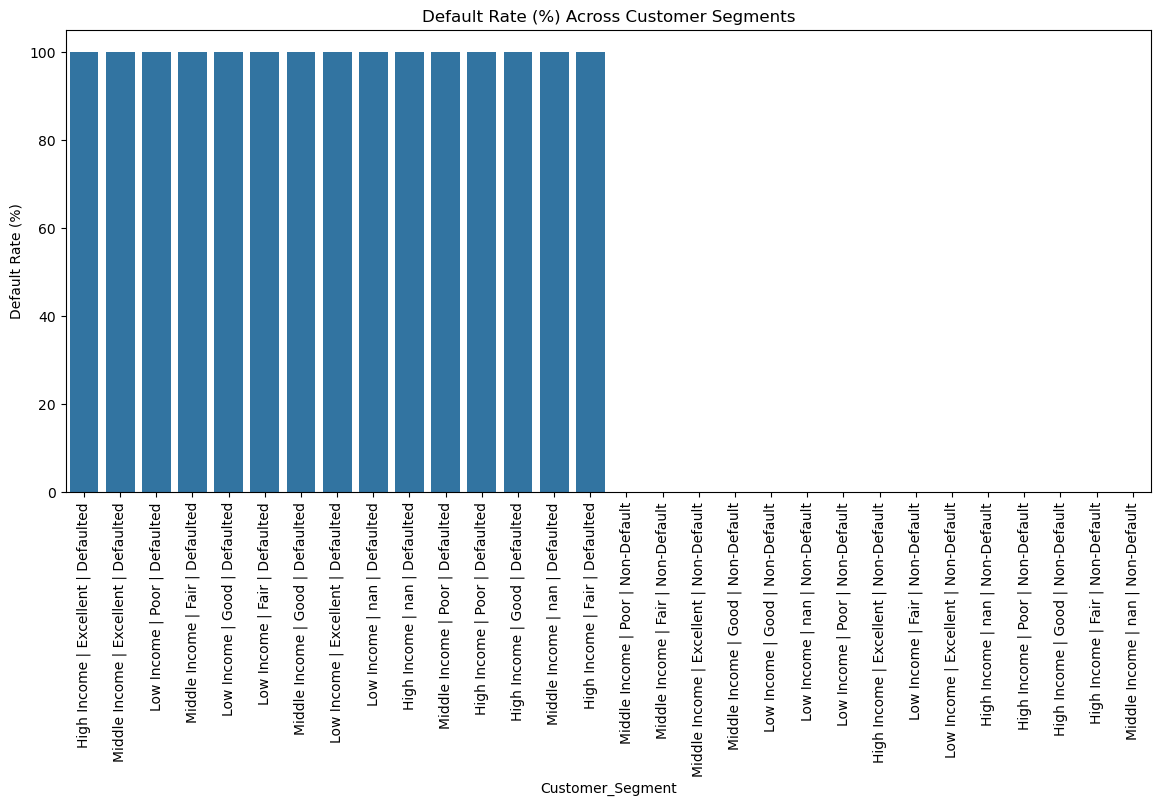

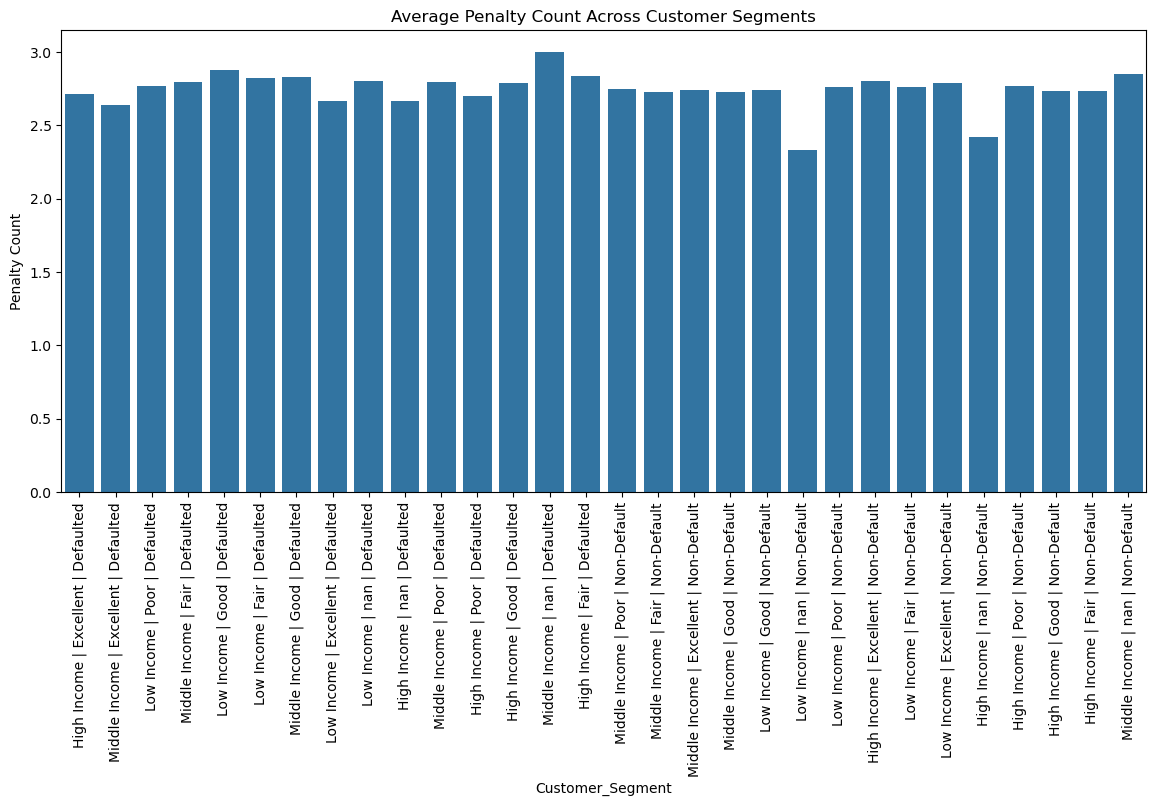

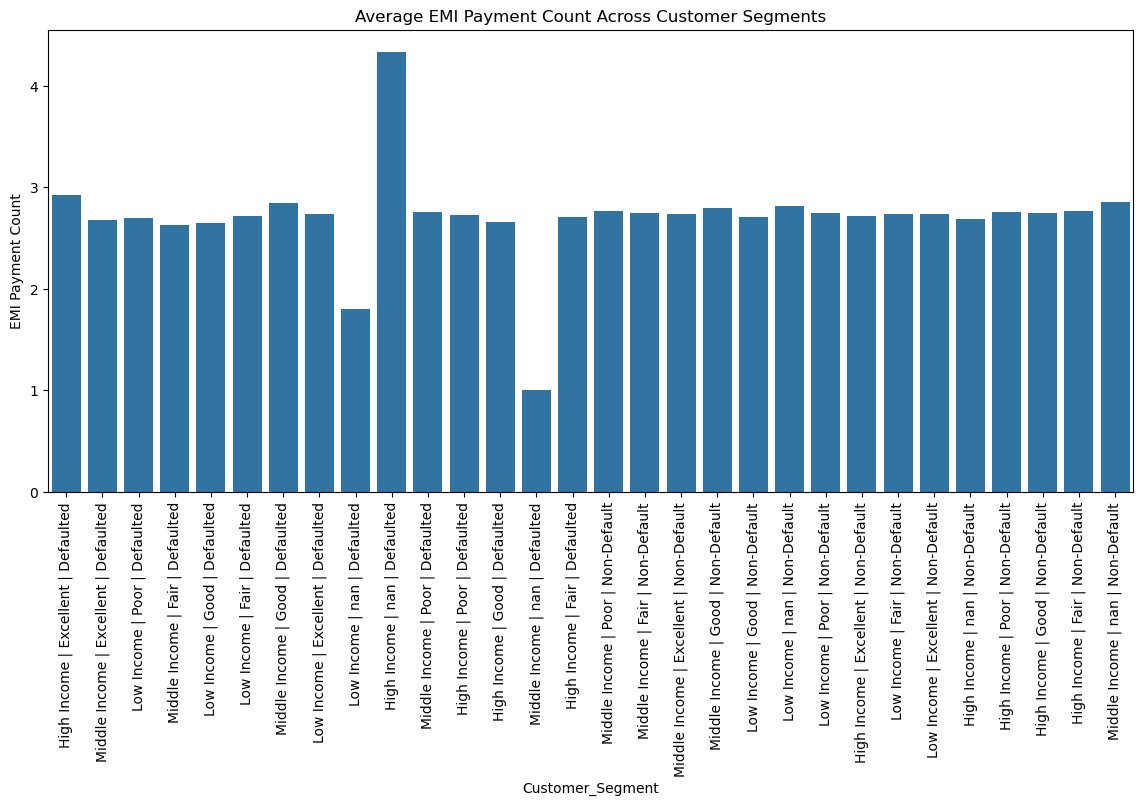

In [305]:
#Analysing Repayment Behaviour across Segments
emi_payments = transactions[transactions['Payment_Type'].str.contains("EMI", case=False, na=False)]
emi_summary = emi_payments.groupby("Loan_ID").agg(
    EMI_Payment_Count=("Transaction_ID", "count"),
    Total_EMI_Paid=("Amount", "sum"),
    Avg_EMI_Payment=("Amount", "mean")
).reset_index()

# Penalty Payments
penalty_payments = transactions[transactions["Payment_Type"].str.contains("Penalty", case=False, na=False)]
penalty_summary = penalty_payments.groupby("Loan_ID").agg(
    Penalty_Count=("Transaction_ID", "count"),
    Total_Penalty_Paid=("Amount", "sum")
).reset_index()

# Merge repayment behaviour into df
df = df.merge(emi_summary, on="Loan_ID", how="left")
df = df.merge(penalty_summary, on="Loan_ID", how="left")

df["EMI_Payment_Count"] = df["EMI_Payment_Count"].fillna(0)
df["Total_EMI_Paid"] = df["Total_EMI_Paid"].fillna(0)
df["Avg_EMI_Payment"] = df["Avg_EMI_Payment"].fillna(0)

df["Penalty_Count"] = df["Penalty_Count"].fillna(0)
df["Total_Penalty_Paid"] = df["Total_Penalty_Paid"].fillna(0)

# Segment-wise repayment behaviour summary
segment_repayment = df.groupby("Customer_Segment").agg(
    Total_Customers=("Customer_ID", "nunique"),
    Total_Loans=("Loan_ID", "count"),
    Avg_Loan_Amount=("Loan_Amount", "mean"),
    Default_Rate=("Default_Flag", "mean"),
    Avg_EMI_Payment_Count=("EMI_Payment_Count", "mean"),
    Avg_Total_EMI_Paid=("Total_EMI_Paid", "mean"),
    Avg_Penalty_Count=("Penalty_Count", "mean"),
    Avg_Total_Penalty_Paid=("Total_Penalty_Paid", "mean"),
    Avg_EMI_Burden=("EMI_Burden_Ratio", "mean")
).reset_index()

segment_repayment["Default_Rate"] = segment_repayment["Default_Rate"] * 100

segment_repayment = segment_repayment.sort_values(by="Default_Rate", ascending=False)

print("\n========== REPAYMENT BEHAVIOUR ACROSS SEGMENTS ==========")
print(segment_repayment.head(20))
print("=========================================================\n")

plt.figure(figsize=(14,6))
sns.barplot(x="Customer_Segment", y="Default_Rate", data=segment_repayment)
plt.xticks(rotation=90)
plt.title("Default Rate (%) Across Customer Segments")
plt.ylabel("Default Rate (%)")
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(x="Customer_Segment", y="Avg_Penalty_Count", data=segment_repayment)
plt.xticks(rotation=90)
plt.title("Average Penalty Count Across Customer Segments")
plt.ylabel("Penalty Count")
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(x="Customer_Segment", y="Avg_EMI_Payment_Count", data=segment_repayment)
plt.xticks(rotation=90)
plt.title("Average EMI Payment Count Across Customer Segments")
plt.ylabel("EMI Payment Count")
plt.show()

## Analysis Tasks 6 : Advanced Statistical Analysis

1. Correlation Analysis for Default risks by examining the correlation between credit_score, loan_amount, Interest_Rate, Overdue_amount and Default_Flag
2. Pairwise Correlation Heatmap to visualiza correlations among key variables like EMI_Amount, Recovery_Rate and Default_Amount
3. Branch level Correlation to explore the relationship between branch performance metrics and overall efficiency


========== CORRELATION MATRIX ==========
                Credit_Score  Loan_Amount  Interest_Rate  Overdue_Amount  \
Credit_Score        1.000000     0.000118       0.002449        0.001570   
Loan_Amount         0.000118     1.000000      -0.003201        0.008405   
Interest_Rate       0.002449    -0.003201       1.000000       -0.002208   
Overdue_Amount      0.001570     0.008405      -0.002208        1.000000   
Default_Flag       -0.001580    -0.003311      -0.003736       -0.000687   

                Default_Flag  
Credit_Score       -0.001580  
Loan_Amount        -0.003311  
Interest_Rate      -0.003736  
Overdue_Amount     -0.000687  
Default_Flag        1.000000  


========== CORRELATION WITH DEFAULT FLAG ==========
Default_Flag      1.000000
Overdue_Amount   -0.000687
Credit_Score     -0.001580
Loan_Amount      -0.003311
Interest_Rate    -0.003736
Name: Default_Flag, dtype: float64



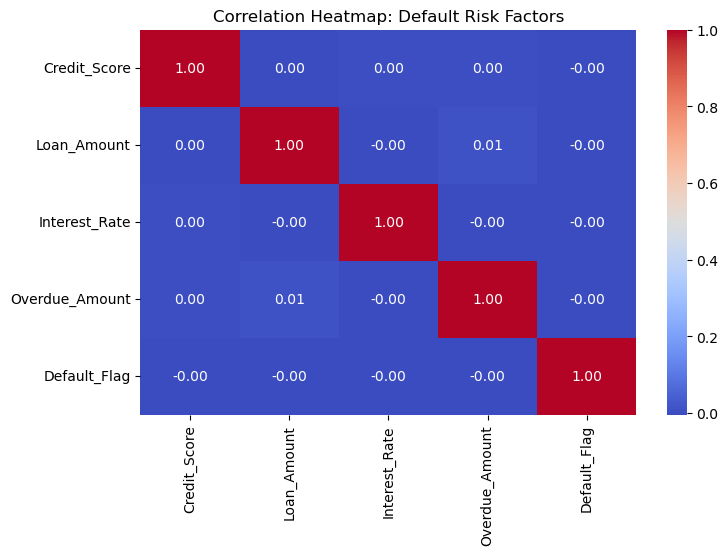

In [306]:
# Correlation Analysis for Default risks

corr_data = df[["Credit_Score", "Loan_Amount", "Interest_Rate", "Overdue_Amount", "Default_Flag"]]

corr_matrix = corr_data.corr()

print("\n========== CORRELATION MATRIX ==========")
print(corr_matrix)
print("========================================\n")

default_corr = corr_matrix["Default_Flag"].sort_values(ascending=False)

print("\n========== CORRELATION WITH DEFAULT FLAG ==========")
print(default_corr)
print("===================================================\n")

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Default Risk Factors")
plt.show()


========== CORRELATION MATRIX ==========
                EMI_Amount  Recovery_Rate  Default_Amount
EMI_Amount        1.000000      -0.001398        0.007617
Recovery_Rate    -0.001398       1.000000       -0.376274
Default_Amount    0.007617      -0.376274        1.000000



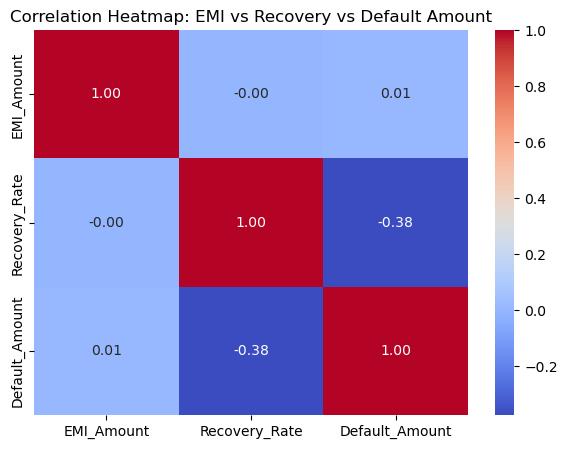

In [307]:
#Pairwise Correlation Heatmap
df = loans.merge(defaults[["Loan_ID", "Default_Amount", "Recovery_Amount"]],
                 on="Loan_ID", how="left")

df["Recovery_Rate"] = np.where(
    df["Default_Amount"] > 0,
    df["Recovery_Amount"] / df["Default_Amount"],
    0
)

corr_data = df[["EMI_Amount", "Recovery_Rate", "Default_Amount"]]

corr_matrix = corr_data.corr()

print("\n========== CORRELATION MATRIX ==========")
print(corr_matrix)
print("========================================\n")

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: EMI vs Recovery vs Default Amount")
plt.show()

## Analysis Tasks 7 : Transaction and Recovery Analysis

1. Analyze penalty payments and overdue trends.
2. Evaluate recovery rates by Default_Reason and Legal_Action.
3. Compare recovery rates across regions and branches


Total Penalty Transactions: 247844

Top 10 Loans with Highest Penalty Amount:
       Loan_ID  Total_Penalty_Amount  Penalty_Count
84233  L089983                365665             11
60827  L064935                352719             11
50466  L053870                342038             10
64012  L068329                336972             11
31110  L033212                331203             10
38902  L041553                330403              9
7850   L008372                326595              8
4376   L004669                326141             11
61761  L065933                324565              8
78051  L083367                322041             10


C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\2405367933.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penalty_txn["Month"] = penalty_txn["Transaction_Date"].dt.to_period("M")


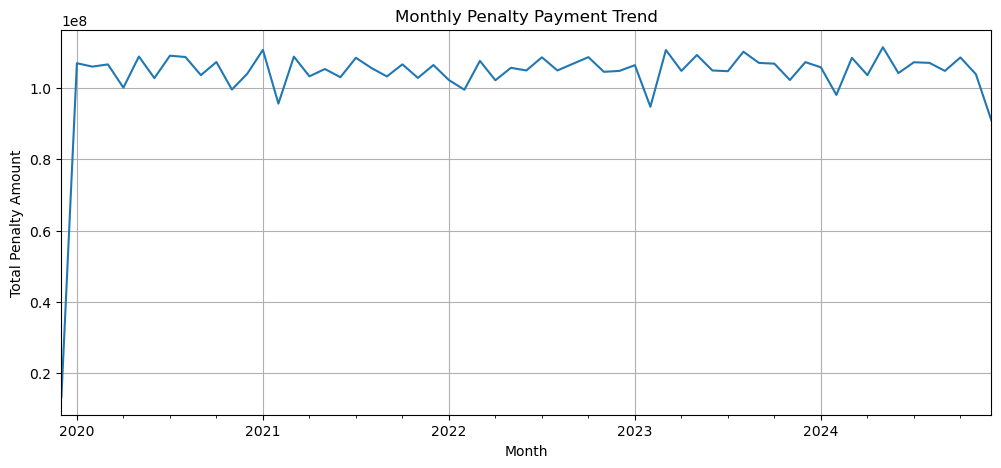

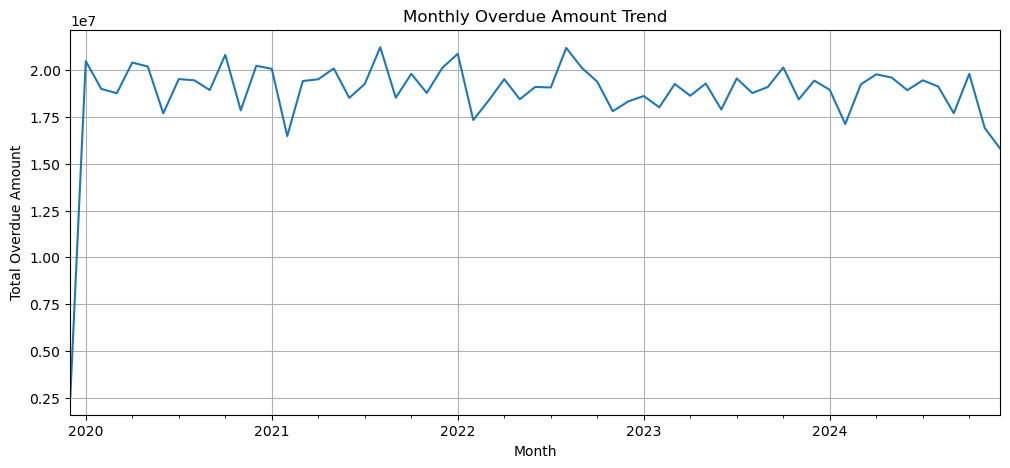


Overdue Trend Summary:
Month
2019-12     2518345
2020-01    20487375
2020-02    19003752
2020-03    18771857
2020-04    20412621
2020-05    20199603
2020-06    17695175
2020-07    19529457
2020-08    19461893
2020-09    18940746
Freq: M, Name: Overdue_Amount, dtype: int64


In [308]:
# Analyzing penalty payments and overdue trends
penalty_txn = transactions[transactions["Payment_Type"].str.contains("Penalty", case=False, na=False)]

print("\nTotal Penalty Transactions:", penalty_txn.shape[0])

penalty_summary = penalty_txn.groupby("Loan_ID").agg(
    Total_Penalty_Amount=("Amount", "sum"),
    Penalty_Count=("Transaction_ID", "count")
).reset_index()

print("\nTop 10 Loans with Highest Penalty Amount:")
print(penalty_summary.sort_values(by="Total_Penalty_Amount", ascending=False).head(10))

penalty_txn["Month"] = penalty_txn["Transaction_Date"].dt.to_period("M")

monthly_penalty = penalty_txn.groupby("Month")["Amount"].sum()

plt.figure(figsize=(12,5))
monthly_penalty.plot()
plt.title("Monthly Penalty Payment Trend")
plt.xlabel("Month")
plt.ylabel("Total Penalty Amount")
plt.grid(True)
plt.show()

if "Overdue_Amount" in loans.columns:
    loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"], errors="coerce")
    loans["Month"] = loans["Disbursal_Date"].dt.to_period("M")

    monthly_overdue = loans.groupby("Month")["Overdue_Amount"].sum()

    plt.figure(figsize=(12,5))
    monthly_overdue.plot()
    plt.title("Monthly Overdue Amount Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Overdue Amount")
    plt.grid(True)
    plt.show()

    print("\nOverdue Trend Summary:")
    print(monthly_overdue.head(10))

else:
    print("\n Overdue_Amount column not found in loans dataset!")


========== RECOVERY RATE BY DEFAULT REASON ==========
      Default_Reason  Total_Default_Amount  Total_Recovery_Amount  \
2  Medical Emergency          1.190815e+08               30263160   
1           Job Loss          1.134765e+08               26835222   
0   Business Failure          1.219295e+08               29818593   
3              Other          1.223211e+08               29002838   

   Avg_Recovery_Rate  Total_Default_Cases  
2           0.415627                 2262  
1           0.403830                 2160  
0           0.402082                 2285  
3           0.389949                 2293  



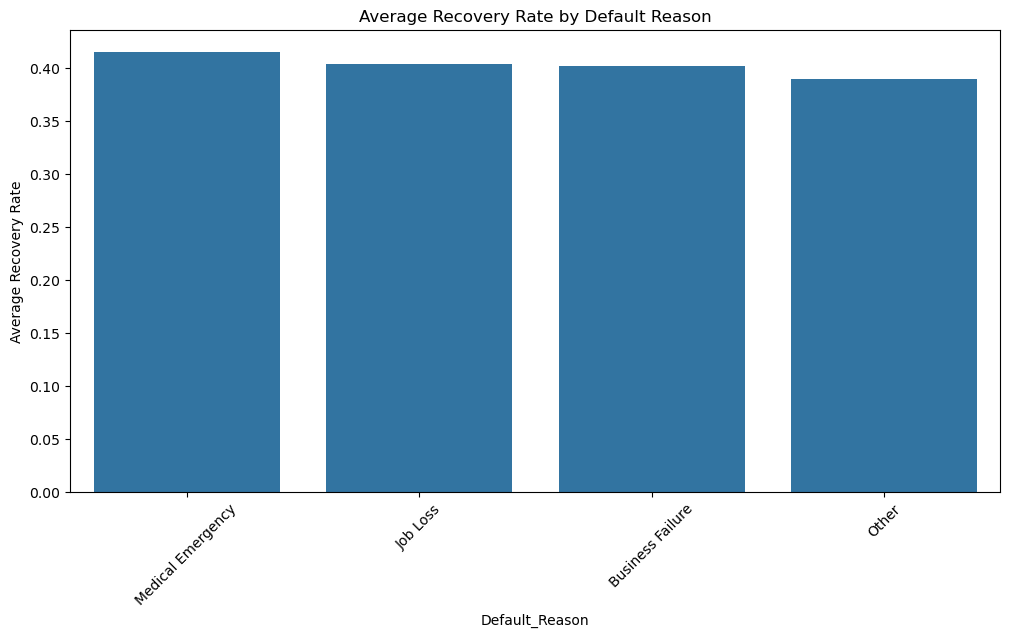


========== RECOVERY RATE BY LEGAL ACTION ==========
  Legal_Action  Total_Default_Amount  Total_Recovery_Amount  \
1          Yes          2.347167e+08               57461364   
0           No          2.420919e+08               58458449   

   Avg_Recovery_Rate  Total_Default_Cases  
1           0.405979                 4450  
0           0.399720                 4550  



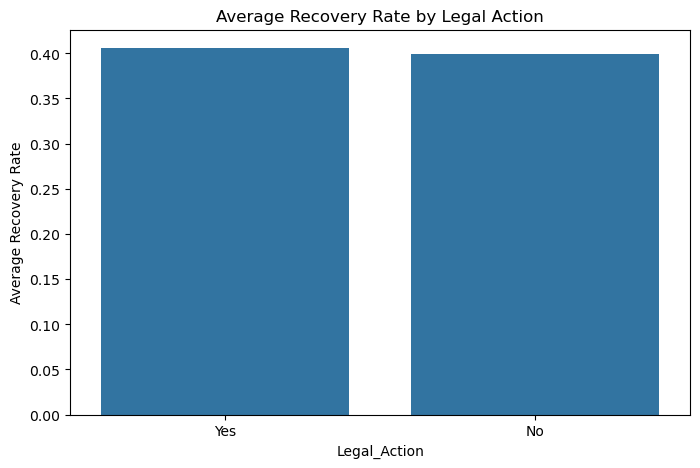


========== RECOVERY RATE BY DEFAULT REASON + LEGAL ACTION ==========
      Default_Reason Legal_Action  Avg_Recovery_Rate  Total_Default_Cases
0   Business Failure           No           0.403277                 1135
1   Business Failure          Yes           0.400903                 1150
2           Job Loss           No           0.390662                 1077
3           Job Loss          Yes           0.416925                 1083
4  Medical Emergency           No           0.418139                 1179
5  Medical Emergency          Yes           0.412893                 1083
6              Other           No           0.385918                 1159
7              Other          Yes           0.394068                 1134



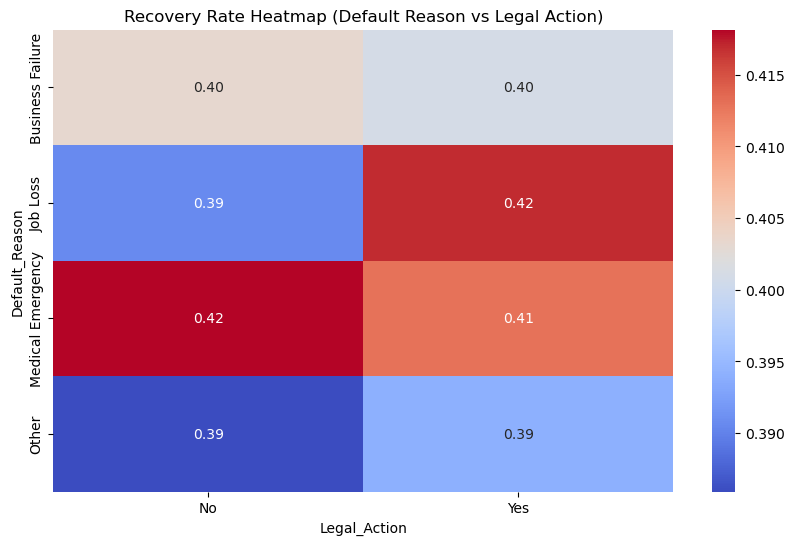

In [309]:
#Evaluating recovery rates by Default_Reason and Legal_Action.
required_cols = ["Default_Amount", "Recovery_Amount", "Default_Reason", "Legal_Action"]

missing_cols = [col for col in required_cols if col not in defaults.columns]

if len(missing_cols) > 0:
    print("Missing required columns in", missing_cols)
    print("Please ensure Default_Reason and Legal_Action exist in the dataset.")
else:
    defaults["Recovery_Rate"] = np.where(
        defaults["Default_Amount"] > 0,
        defaults["Recovery_Amount"] / defaults["Default_Amount"],
        0
    )

    recovery_by_reason = defaults.groupby("Default_Reason").agg(
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Avg_Recovery_Rate=("Recovery_Rate", "mean"),
        Total_Default_Cases=("Default_ID", "count")
    ).reset_index()

    recovery_by_reason = recovery_by_reason.sort_values(by="Avg_Recovery_Rate", ascending=False)

    print("\n========== RECOVERY RATE BY DEFAULT REASON ==========")
    print(recovery_by_reason)
    print("=====================================================\n")

    # Plot Recovery Rate by Default Reason
    plt.figure(figsize=(12,6))
    sns.barplot(x="Default_Reason", y="Avg_Recovery_Rate", data=recovery_by_reason)
    plt.xticks(rotation=45)
    plt.title("Average Recovery Rate by Default Reason")
    plt.ylabel("Average Recovery Rate")
    plt.show()

    recovery_by_legal = defaults.groupby("Legal_Action").agg(
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Avg_Recovery_Rate=("Recovery_Rate", "mean"),
        Total_Default_Cases=("Default_ID", "count")
    ).reset_index()

    recovery_by_legal = recovery_by_legal.sort_values(by="Avg_Recovery_Rate", ascending=False)

    print("\n========== RECOVERY RATE BY LEGAL ACTION ==========")
    print(recovery_by_legal)
    print("===================================================\n")

    # Plot Recovery Rate by Legal Action
    plt.figure(figsize=(8,5))
    sns.barplot(x="Legal_Action", y="Avg_Recovery_Rate", data=recovery_by_legal)
    plt.title("Average Recovery Rate by Legal Action")
    plt.ylabel("Average Recovery Rate")
    plt.show()

    recovery_reason_legal = defaults.groupby(["Default_Reason", "Legal_Action"]).agg(
        Avg_Recovery_Rate=("Recovery_Rate", "mean"),
        Total_Default_Cases=("Default_ID", "count")
    ).reset_index()

    print("\n========== RECOVERY RATE BY DEFAULT REASON + LEGAL ACTION ==========")
    print(recovery_reason_legal)
    print("===============================================================\n")

    pivot_table = recovery_reason_legal.pivot(index="Default_Reason",
                                              columns="Legal_Action",
                                              values="Avg_Recovery_Rate")

    plt.figure(figsize=(10,6))
    sns.heatmap(pivot_table, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Recovery Rate Heatmap (Default Reason vs Legal Action)")
    plt.show()


## Analysis Tasks 8 : EMI Analysis

1. Analyze the relationship between EMI amounts and default probabilities.
2. Identify thresholds for EMI amounts where defaults are most likely.
3. Compare EMI trends across loan types.

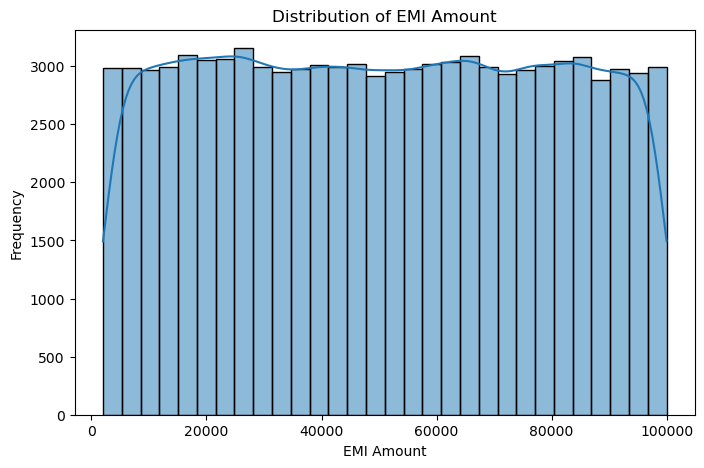

C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\2451621433.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_default_prob = loans.groupby("EMI_Bucket").agg(



========== DEFAULT PROBABILITY BY EMI BUCKET ==========
            EMI_Bucket  Total_Loans  Defaulted_Loans  Default_Probability
0  (2000.999, 11859.9]         9000              835             9.277778
1   (11859.9, 21519.4]         9000              843             9.366667
2   (21519.4, 31089.7]         9000              870             9.666667
3   (31089.7, 40951.2]         9000              809             8.988889
4   (40951.2, 50861.0]         9002              861             9.564541
5   (50861.0, 60714.0]         8999              874             9.712190
6   (60714.0, 70394.9]         8999              887             9.856651
7   (70394.9, 80297.0]         9002              831             9.231282
8   (80297.0, 90083.0]         8999              878             9.756640
9  (90083.0, 100000.0]         8999              851             9.456606



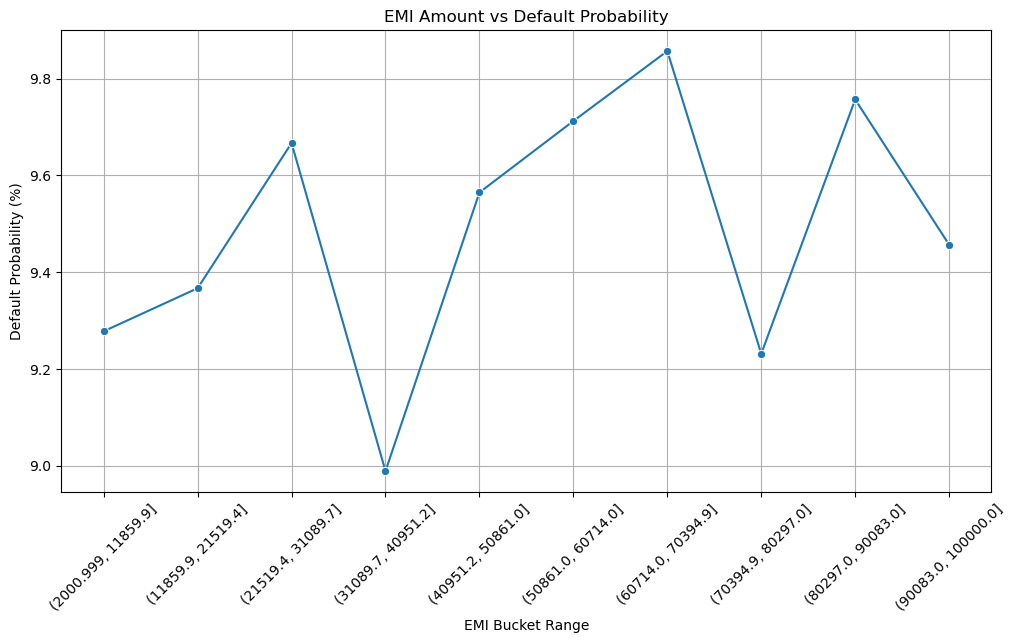

In [310]:
# Analysing the relationship between EMI amounts and default probabilites

plt.figure(figsize=(8,5))
sns.histplot(loans["EMI_Amount"], bins=30, kde=True)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()


loans["EMI_Bucket"] = pd.qcut(loans["EMI_Amount"], q=10, duplicates="drop")

emi_default_prob = loans.groupby("EMI_Bucket").agg(
    Total_Loans=("Loan_ID", "count"),
    Defaulted_Loans=("Default_Flag", "sum"),
    Default_Probability=("Default_Flag", "mean")
    ).reset_index()

emi_default_prob["Default_Probability"] = emi_default_prob["Default_Probability"] * 100

print("\n========== DEFAULT PROBABILITY BY EMI BUCKET ==========")
print(emi_default_prob)
print("======================================================\n")

plt.figure(figsize=(12,6))
sns.lineplot(x=emi_default_prob["EMI_Bucket"].astype(str),
                y=emi_default_prob["Default_Probability"],
                marker="o")

plt.xticks(rotation=45)
plt.title("EMI Amount vs Default Probability")
plt.xlabel("EMI Bucket Range")
plt.ylabel("Default Probability (%)")
plt.grid(True)
plt.show()

C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\626778714.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_default = loans.groupby("EMI_Bucket").agg(



========== DEFAULT RATE BY EMI BUCKET ==========
            EMI_Bucket  Total_Loans  Defaulted_Loans  Default_Rate  \
0  (2000.999, 11859.9]         9000              835      9.277778   
1   (11859.9, 21519.4]         9000              843      9.366667   
2   (21519.4, 31089.7]         9000              870      9.666667   
3   (31089.7, 40951.2]         9000              809      8.988889   
4   (40951.2, 50861.0]         9002              861      9.564541   
5   (50861.0, 60714.0]         8999              874      9.712190   
6   (60714.0, 70394.9]         8999              887      9.856651   
7   (70394.9, 80297.0]         9002              831      9.231282   
8   (80297.0, 90083.0]         8999              878      9.756640   
9  (90083.0, 100000.0]         8999              851      9.456606   

        Avg_EMI  
0   6938.656667  
1  16701.996889  
2  26271.646667  
3  36039.923778  
4  45891.502333  
5  55790.223692  
6  65527.913213  
7  75377.650300  
8  85154.354595  

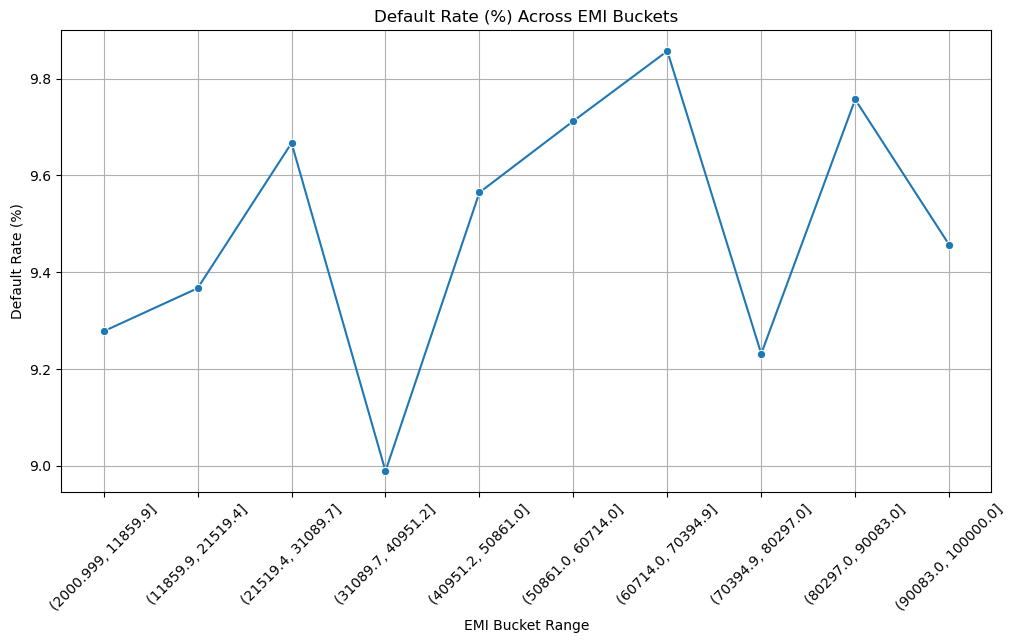

In [311]:
# Identifying thresholds for EMI amounts where defaults are most likely
bucket_default = loans.groupby("EMI_Bucket").agg(
        Total_Loans=("Loan_ID", "count"),
        Defaulted_Loans=("Default_Flag", "sum"),
        Default_Rate=("Default_Flag", "mean"),
        Avg_EMI=("EMI_Amount", "mean")
    ).reset_index()

bucket_default["Default_Rate"] = bucket_default["Default_Rate"] * 100

print("\n========== DEFAULT RATE BY EMI BUCKET ==========")
print(bucket_default)
print("================================================\n")

highest_bucket = bucket_default.loc[bucket_default["Default_Rate"].idxmax()]

print("\n========== EMI BUCKET WITH HIGHEST DEFAULT RATE ==========")
print(highest_bucket)
print("=========================================================\n")

bucket_default["Default_Rate_Change"] = bucket_default["Default_Rate"].diff()

threshold_row = bucket_default.loc[bucket_default["Default_Rate_Change"].idxmax()]

print("\n========== EMI THRESHOLD WHERE DEFAULTS INCREASE MOST ==========")
print("Threshold EMI Bucket:", threshold_row["EMI_Bucket"])
print("Average EMI in Bucket:", round(threshold_row["Avg_EMI"], 2))
print("Default Rate Jump (%):", round(threshold_row["Default_Rate_Change"], 2))
print("===============================================================\n")

plt.figure(figsize=(12,6))
sns.lineplot(x=bucket_default["EMI_Bucket"].astype(str),
             y=bucket_default["Default_Rate"],
              marker="o")

plt.xticks(rotation=45)
plt.title("Default Rate (%) Across EMI Buckets")
plt.xlabel("EMI Bucket Range")
plt.ylabel("Default Rate (%)")
plt.grid(True)
plt.show()


========== EMI SUMMARY BY LOAN TYPE ==========
   Loan_Term  Total_Loans       Avg_EMI  Median_EMI  Max_EMI  Min_EMI
0         12        17850  50996.724986     50750.5    99998     2001
4         60        18081  50974.058017     51110.0    99993     2007
3         48        18025  50923.388627     51066.0    99998     2006
1         24        17963  50805.671658     50688.0    99999     2011
2         36        18081  50672.334827     50667.0   100000     2002



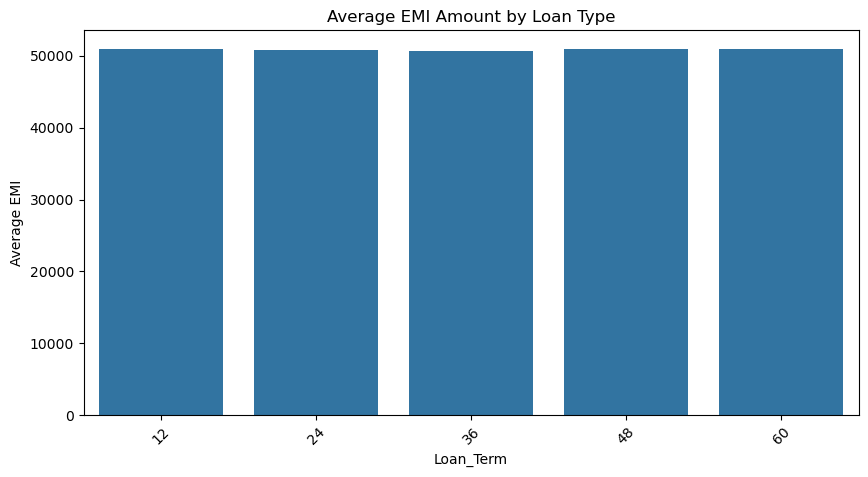

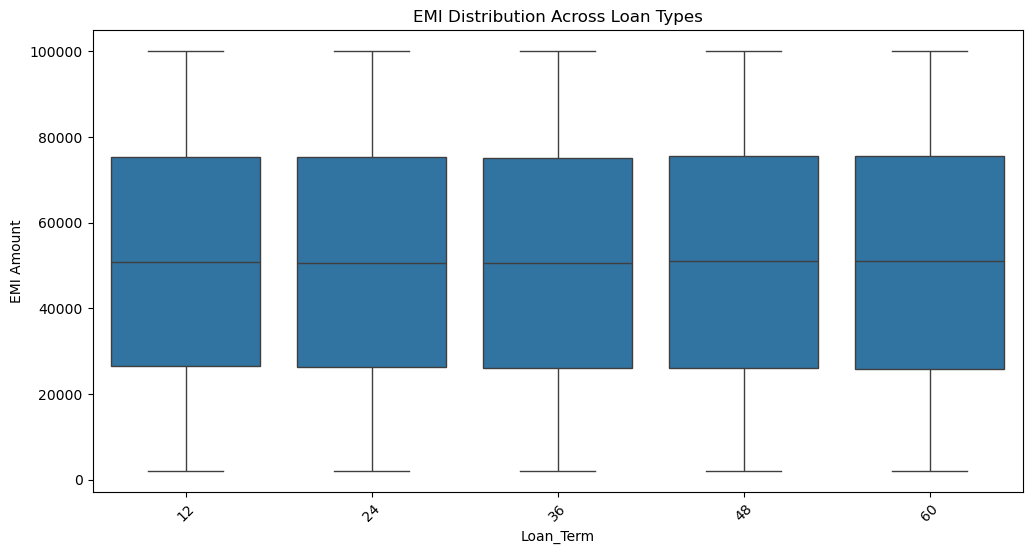

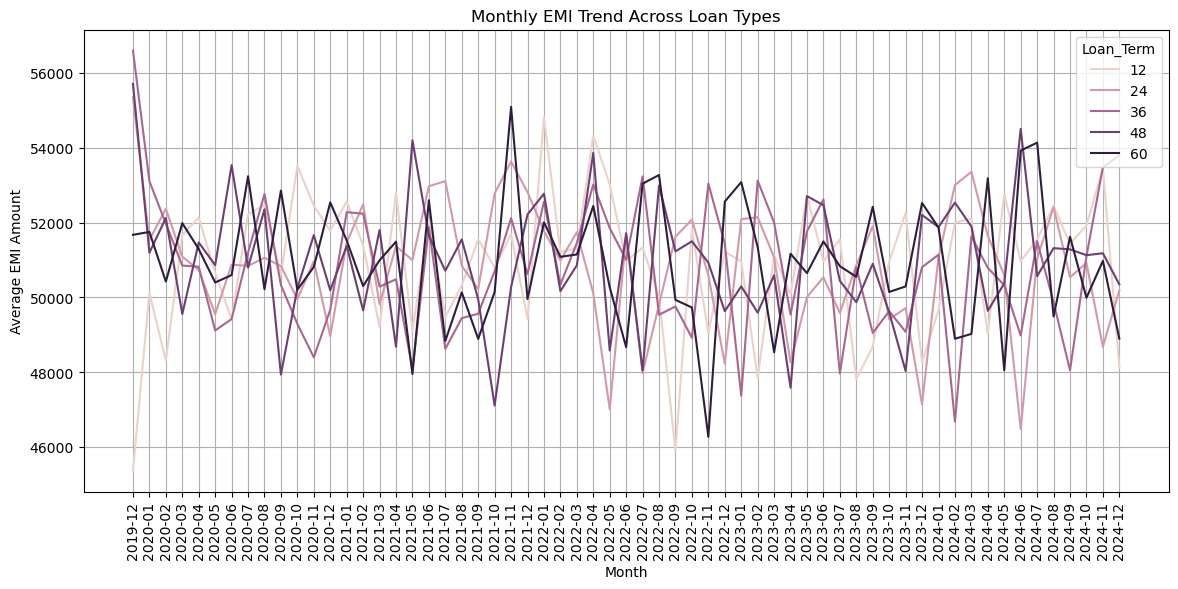


Monthly EMI Trend Data:
     Month  Loan_Term    EMI_Amount
0  2019-12         12  45371.320755
1  2019-12         24  55353.263158
2  2019-12         36  56600.666667
3  2019-12         48  55710.500000
4  2019-12         60  51675.052632


In [312]:
# Comparing EMI trends across loan types
required_cols = ["Loan_Term", "EMI_Amount"]

missing_cols = [col for col in required_cols if col not in loans.columns]

emi_by_type = loans.groupby("Loan_Term").agg(
        Total_Loans=("Loan_ID", "count"),
        Avg_EMI=("EMI_Amount", "mean"),
        Median_EMI=("EMI_Amount", "median"),
        Max_EMI=("EMI_Amount", "max"),
        Min_EMI=("EMI_Amount", "min")
    ).reset_index()

emi_by_type = emi_by_type.sort_values(by="Avg_EMI", ascending=False)

print("\n========== EMI SUMMARY BY LOAN TYPE ==========")
print(emi_by_type)
print("=============================================\n")

plt.figure(figsize=(10,5))
sns.barplot(x="Loan_Term", y="Avg_EMI", data=emi_by_type)
plt.title("Average EMI Amount by Loan Type")
plt.xticks(rotation=45)
plt.ylabel("Average EMI")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x="Loan_Term", y="EMI_Amount", data=loans)
plt.title("EMI Distribution Across Loan Types")
plt.xticks(rotation=45)
plt.ylabel("EMI Amount")
plt.show()

if "Disbursal_Date" in loans.columns:
    loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"], errors="coerce")
    loans["Month"] = loans["Disbursal_Date"].dt.to_period("M")

    monthly_emi_trend = loans.groupby(["Month", "Loan_Term"])["EMI_Amount"].mean().reset_index()

    monthly_emi_trend["Month"] = monthly_emi_trend["Month"].astype(str)

    plt.figure(figsize=(14,6))
    sns.lineplot(x="Month", y="EMI_Amount", hue="Loan_Term", data=monthly_emi_trend)
    plt.title("Monthly EMI Trend Across Loan Types")
    plt.xticks(rotation=90)
    plt.ylabel("Average EMI Amount")
    plt.grid(True)
    plt.show()

    print("\nMonthly EMI Trend Data:")
    print(monthly_emi_trend.head())

else:
    print("Disbursal_Date column not found. Monthly EMI trend cannot be calculated.")


## Analysis Tasks 9 : Loan Application Insights

1. Calculate approval and rejection rates for loan applications
2. Identify the most common reasons for loan rejection.
3. Compare application processing fees between approves and rejected applications.

In [313]:
#Calculating approval and rejection rates for loan applications
total_apps = len(applications)

approved_apps = len(applications[applications["Approval_Status"] == "Approved"])
rejected_apps = len(applications[applications["Approval_Status"] == "Rejected"])

approval_rate = (approved_apps / total_apps) * 100
rejection_rate = (rejected_apps / total_apps) * 100

print("\n========== LOAN APPLICATION APPROVAL/REJECTION SUMMARY ==========")
print("Total Applications :", total_apps)
print("Approved           :", approved_apps)
print("Rejected           :", rejected_apps)
print(f"Approval Rate (%)  : {approval_rate:.2f}%")
print(f"Rejection Rate (%) : {rejection_rate:.2f}%")
print("===============================================================\n")


========== LOAN APPLICATION APPROVAL/REJECTION SUMMARY ==========
Total Applications : 82600
Approved           : 70000
Rejected           : 12600
Approval Rate (%)  : 84.75%
Rejection Rate (%) : 15.25%




Total Rejected Applications: 12600

========== MOST COMMON LOAN REJECTION REASONS ==========
       Rejection_Reason  Count  Percentage
0      Low Credit Score   4297   34.103175
1  Incomplete Documents   4204   33.365079
2   Insufficient Income   4099   32.531746



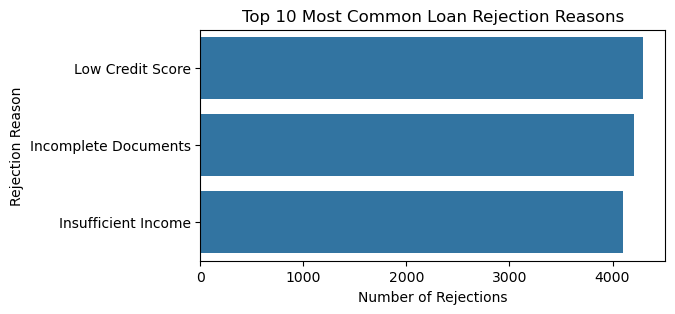

In [314]:
#Reasons for most loan rejections
rejected_apps = applications[applications["Approval_Status"] == "Rejected"]

print("\nTotal Rejected Applications:", rejected_apps.shape[0])

rejection_reason_counts = rejected_apps["Rejection_Reason"].value_counts().reset_index()
rejection_reason_counts.columns = ["Rejection_Reason", "Count"]

rejection_reason_counts["Percentage"] = (rejection_reason_counts["Count"] / rejected_apps.shape[0]) * 100

print("\n========== MOST COMMON LOAN REJECTION REASONS ==========")
print(rejection_reason_counts.head(10))
print("=======================================================\n")

plt.figure(figsize=(6,3))
sns.barplot(x="Count", y="Rejection_Reason", data=rejection_reason_counts.head(10))
plt.title("Top 10 Most Common Loan Rejection Reasons")
plt.xlabel("Number of Rejections")
plt.ylabel("Rejection Reason")
plt.show()


========== PROCESSING FEE SUMMARY ==========
                   count         mean          std    min     25%     50%  \
Approval_Status                                                             
Approved         70000.0  5252.395014  2741.573413  500.0  2895.0  5256.0   
Rejected         12600.0  5255.141587  2721.010522  500.0  2897.5  5271.0   

                    75%      max  
Approval_Status                   
Approved         7626.0  10000.0  
Rejected         7602.0   9998.0  



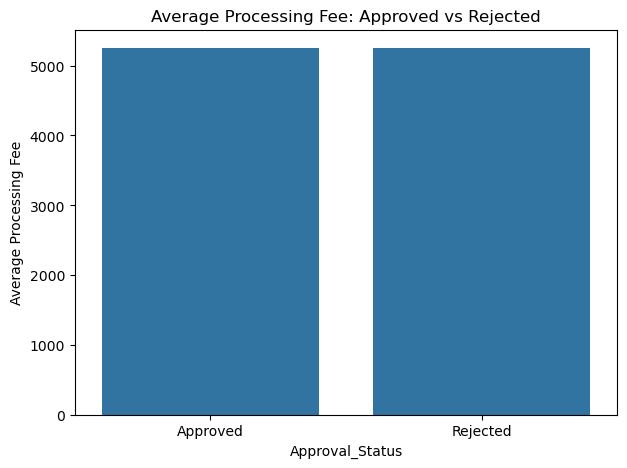

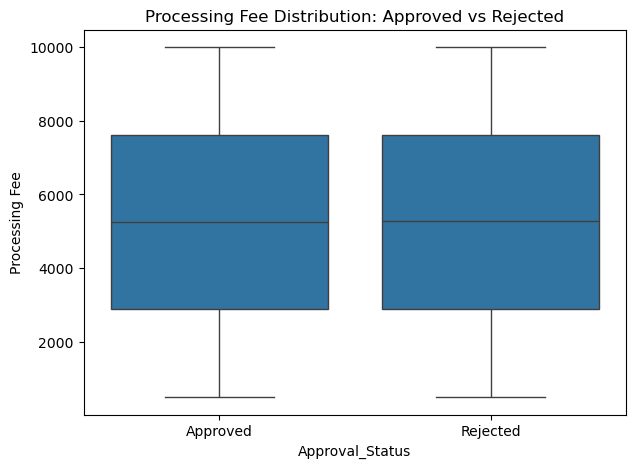

In [315]:
# Comparing application processing fees between approved and rejected applications
approved = applications[applications["Approval_Status"] == "Approved"]
rejected = applications[applications["Approval_Status"] == "Rejected"]

summary = applications.groupby("Approval_Status")["Processing_Fee"].describe()

print("\n========== PROCESSING FEE SUMMARY ==========")
print(summary)
print("===========================================\n")

mean_fee = applications.groupby("Approval_Status")["Processing_Fee"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(x="Approval_Status", y="Processing_Fee", data=mean_fee)
plt.title("Average Processing Fee: Approved vs Rejected")
plt.ylabel("Average Processing Fee")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Approval_Status", y="Processing_Fee", data=applications)
plt.title("Processing Fee Distribution: Approved vs Rejected")
plt.ylabel("Processing Fee")
plt.show()

## Analysis Tasks 10 : Recovery Effectivemess

1. Determine the effectiveness of recovery efforts by calculating the ratio of Recovery_Amouont to Default_Amount.
2. Compare recovery rates for defaults with and withoout legal actions.

In [316]:
# Effectiveness of recovery efforts
defaults["Recovery_Effectiveness_Ratio"] = np.where(
        defaults["Default_Amount"] > 0,
        defaults["Recovery_Amount"] / defaults["Default_Amount"],
        0
    )

print("\n========== RECOVERY EFFECTIVENESS SUMMARY ==========")
print(defaults["Recovery_Effectiveness_Ratio"].describe())
print("====================================================\n")

top_recovery = defaults.sort_values(by="Recovery_Effectiveness_Ratio", ascending=False).head(10)
low_recovery = defaults.sort_values(by="Recovery_Effectiveness_Ratio", ascending=True).head(10)

print("\n========== TOP 10 BEST RECOVERY CASES ==========")
print(top_recovery[["Loan_ID", "Default_Amount", "Recovery_Amount", "Recovery_Effectiveness_Ratio"]])
print("================================================\n")

print("\n========== TOP 10 WORST RECOVERY CASES ==========")
print(low_recovery[["Loan_ID", "Default_Amount", "Recovery_Amount", "Recovery_Effectiveness_Ratio"]])
print("================================================\n")


========== RECOVERY EFFECTIVENESS SUMMARY ==========
count    9000.000000
mean        0.402815
std         0.819398
min         0.000000
25%         0.000000
50%         0.022770
75%         0.482636
max         8.312821
Name: Recovery_Effectiveness_Ratio, dtype: float64


========== TOP 10 BEST RECOVERY CASES ==========
      Loan_ID  Default_Amount  Recovery_Amount  Recovery_Effectiveness_Ratio
107   L039294         5955.86            49510                      8.312821
3333  L018783         5955.86            49365                      8.288476
4705  L066514         5955.86            48112                      8.078095
4270  L062263         5955.86            46905                      7.875437
7440  L082490         5955.86            46788                      7.855792
6489  L034832         6201.00            48064                      7.751008
4040  L078151         5955.86            45739                      7.679663
4142  L015851         5955.86            45382              


========== RECOVERY RATE COMPARISON (LEGAL ACTION) ==========
  Legal_Action  Total_Default_Amount  Total_Recovery_Amount  \
0           No          2.420919e+08               58458449   
1          Yes          2.347167e+08               57461364   

   Avg_Recovery_Rate  Total_Cases  Overall_Recovery_Rate  
0           0.399720         4550               0.241472  
1           0.405979         4450               0.244812  



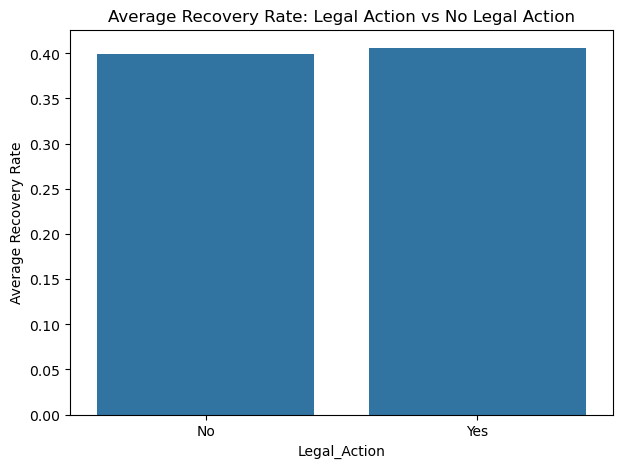

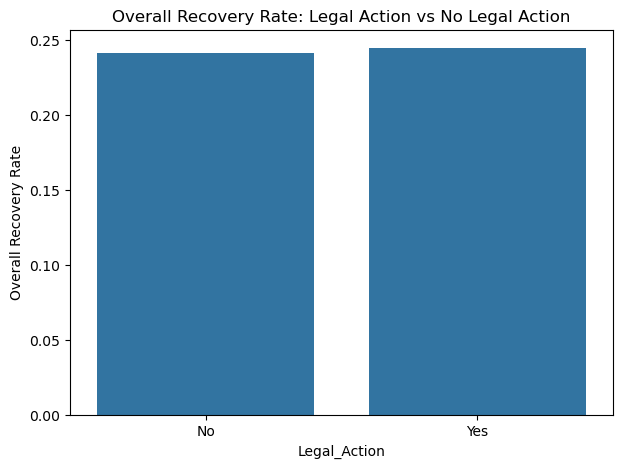

In [317]:
#Comparing recovery rates for defaulters with and without legal actions
defaults["Recovery_Rate"] = np.where(
        defaults["Default_Amount"] > 0,
        defaults["Recovery_Amount"] / defaults["Default_Amount"],
        0
    )

recovery_comparison = defaults.groupby("Legal_Action").agg(
    Total_Default_Amount=("Default_Amount", "sum"),
    Total_Recovery_Amount=("Recovery_Amount", "sum"),
    Avg_Recovery_Rate=("Recovery_Rate", "mean"),
    Total_Cases=("Default_ID", "count")
    ).reset_index()

recovery_comparison["Overall_Recovery_Rate"] = (recovery_comparison["Total_Recovery_Amount"] / recovery_comparison["Total_Default_Amount"])

print("\n========== RECOVERY RATE COMPARISON (LEGAL ACTION) ==========")
print(recovery_comparison)
print("============================================================\n")

plt.figure(figsize=(7,5))
sns.barplot(x="Legal_Action", y="Avg_Recovery_Rate", data=recovery_comparison)
plt.title("Average Recovery Rate: Legal Action vs No Legal Action")
plt.ylabel("Average Recovery Rate")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x="Legal_Action", y="Overall_Recovery_Rate", data=recovery_comparison)
plt.title("Overall Recovery Rate: Legal Action vs No Legal Action")
plt.ylabel("Overall Recovery Rate")
plt.show()


## Analysis Tasks 12 : Profitability Analysis

1. Calculate the total interest income generated across all loan
2. Identify the most profitable loan purposes based on interest earnings

In [318]:
# total Interest income generated across all loans
loans["Interest_Income"] = loans["Loan_Amount"] * (loans["Interest_Rate"] / 100) * (loans["Loan_Term"] / 12)

total_interest_income = loans["Interest_Income"].sum()

print("\n========== TOTAL INTEREST INCOME ==========")
print("Total Interest Income Across All Loans:", round(total_interest_income, 2))
print("==========================================\n")


========== TOTAL INTEREST INCOME ==========
Total Interest Income Across All Loans: 75037994461.59



## Analysis Tasks 13 : Geospatial Analysis

1. Map the distribution of active loans across regions.
2. Compare default rates across different geographic regions

      Region  Total_Active_Loans  Loan_Share_%
0      North               11965     23.516579
1      South                9235     18.150907
2       East                8929     17.549480
3    Central                8715     17.128874
4       West                6861     13.484935
5  Northeast                5174     10.169225


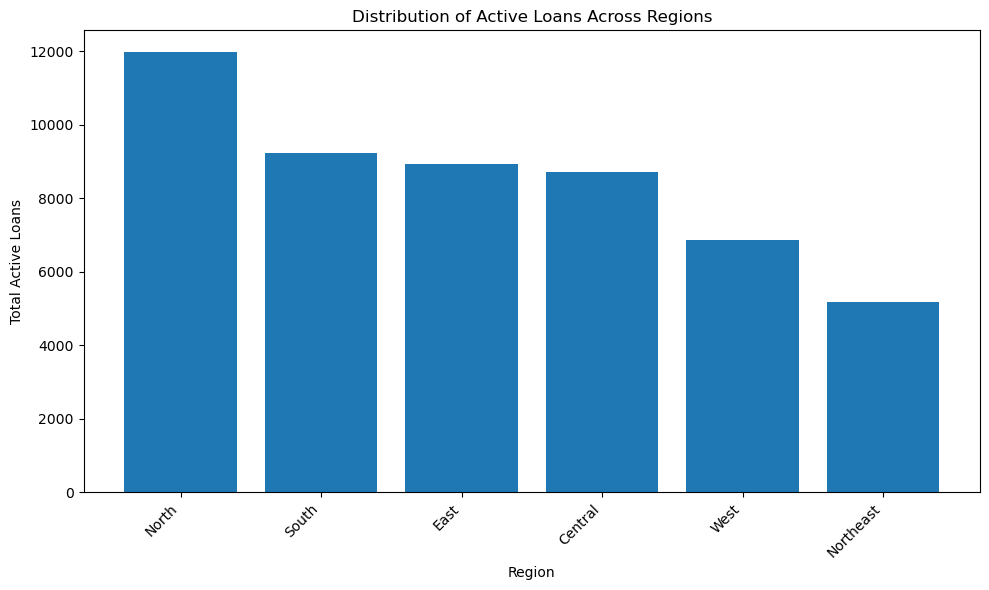

In [319]:
# Mapping the distribution of active loans across regions
region_loans = (
    branches.groupby("Region")["Total_Active_Loans"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calculate distribution (percentage share)
region_loans["Loan_Share_%"] = (
    region_loans["Total_Active_Loans"] / region_loans["Total_Active_Loans"].sum()
) * 100

print(region_loans)

# Plot distribution
plt.figure(figsize=(10,6))
plt.bar(region_loans["Region"], region_loans["Total_Active_Loans"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Active Loans Across Regions")
plt.xlabel("Region")
plt.ylabel("Total Active Loans")
plt.tight_layout()
plt.show()

## Analysis Tasks 14 : Default Trends

1. Analyze the number of defaults over time to identify patterns
2. Calculate the average default amount for different loan purposes.
3. Compare default rates across customer income categories.

## Analysis Tasks 17 : Customer Behaviour Analysis

1. Categorize customers based on their repayment behaviour
2. Analyze patterns in loan approval and rejection reasons segmented by customer demographics
3. Identify high value customers with consistent repayment histories

In [339]:
#Categorizing customers based on their repayment behaviour

customer_repay = loans.groupby("Customer_ID").agg(
    Total_Loans=("Loan_ID", "count"),
    Total_Defaults=("Default_Flag", "sum"),
    Total_Penalties=("Penalty_Count", "sum")
).reset_index()

def repayment_category(row):
    if row["Total_Defaults"] >= 2:
        return "Frequent Defaulter"
    elif row["Total_Defaults"] == 1:
        return "Occasional Defaulter"
    elif row["Total_Penalties"] > 0:
        return "Late Payer (Penalties)"
    else:
        return "Always On Time"

customer_repay["Repayment_Behaviour"] = customer_repay.apply(repayment_category, axis=1)

customer_repay = customer_repay.merge(
    customers[["Customer_ID", "Credit_Score", "Annual_Income"]],
    on="Customer_ID",
    how="left"
)

behaviour_summary = customer_repay["Repayment_Behaviour"].value_counts().reset_index()
behaviour_summary.columns = ["Repayment_Behaviour", "Total_Customers"]

print("\n========== CUSTOMER REPAYMENT BEHAVIOUR SUMMARY ==========")
print(behaviour_summary)
print("=========================================================\n")

print("\nSample Categorized Customers:")
print(customer_repay.head(20))


========== CUSTOMER REPAYMENT BEHAVIOUR SUMMARY ==========
      Repayment_Behaviour  Total_Customers
0  Late Payer (Penalties)            41190
1    Occasional Defaulter             7527
2          Always On Time             1465
3      Frequent Defaulter              494


Sample Categorized Customers:
   Customer_ID  Total_Loans  Total_Defaults  Total_Penalties  \
0      C000003            2               0              2.0   
1      C000004            3               0              5.0   
2      C000005            1               0              1.0   
3      C000007            2               0              5.0   
4      C000008            1               0              2.0   
5      C000011            2               0              9.0   
6      C000012            1               0              3.0   
7      C000013            6               0             11.0   
8      C000016            1               0              4.0   
9      C000017            2               0          


========== APPROVAL RATE BY EMPLOYMENT STATUS ==========
  Employment_Status  Total_Applications  Approved  Rejected  Approval_Rate  \
0          Salaried               27582     23452      4130      85.026467   
1     Self-Employed               27492     23346      4146      84.919249   
2        Unemployed               27526     23202      4324      84.291216   

   Rejection_Rate  
0       14.973533  
1       15.080751  
2       15.708784  



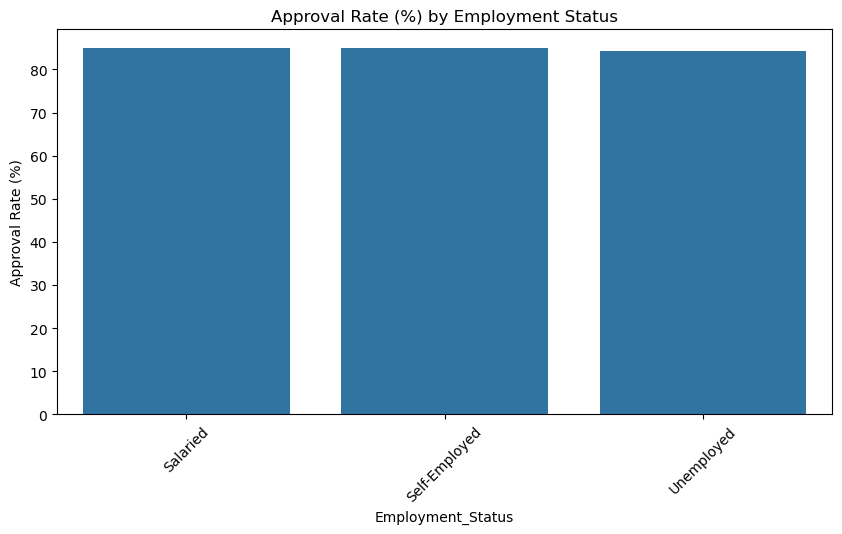

C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\4100602049.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_approval = df.groupby("Income_Segment").agg(



========== APPROVAL RATE BY INCOME SEGMENT ==========
  Income_Segment  Total_Applications  Approved  Rejected  Approval_Rate  \
0     Low Income               27533     23291      4242      84.593034   
1  Middle Income               27533     23383      4150      84.927178   
2    High Income               27534     23326      4208      84.717077   

   Rejection_Rate  
0       15.406966  
1       15.072822  
2       15.282923  



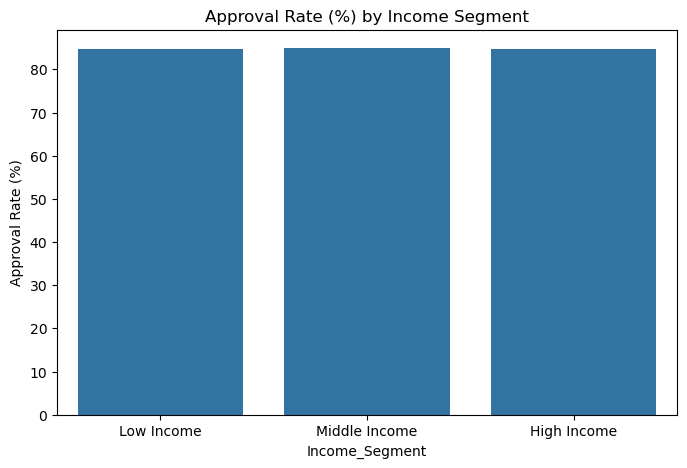

C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\4100602049.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_approval = df.groupby("Credit_Segment").agg(



========== APPROVAL RATE BY CREDIT SCORE SEGMENT ==========
  Credit_Segment  Total_Applications  Approved  Rejected  Approval_Rate  \
0           Poor               37711     31905      5806      84.603962   
1           Fair               14963     12631      2332      84.414890   
2           Good               14861     12633      2228      85.007738   
3      Excellent               14900     12694      2206      85.194631   

   Rejection_Rate  
0       15.396038  
1       15.585110  
2       14.992262  
3       14.805369  



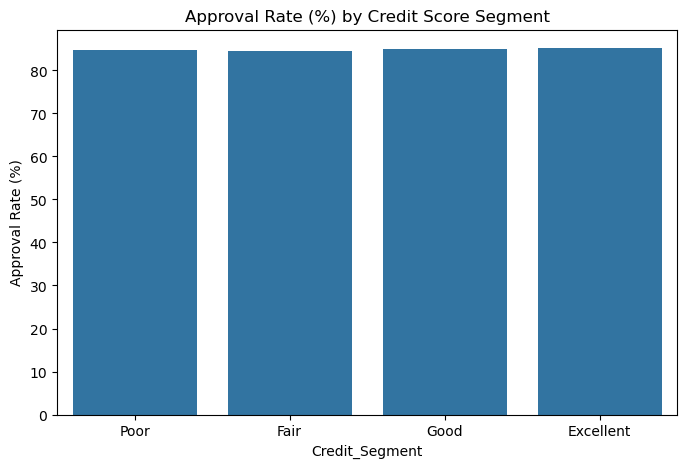


========== TOP REJECTION REASONS BY EMPLOYMENT STATUS ==========
  Employment_Status      Rejection_Reason  Count
0          Salaried  Incomplete Documents   1422
2          Salaried      Low Credit Score   1378
1          Salaried   Insufficient Income   1330
5     Self-Employed      Low Credit Score   1443
4     Self-Employed   Insufficient Income   1365
3     Self-Employed  Incomplete Documents   1338
8        Unemployed      Low Credit Score   1476
6        Unemployed  Incomplete Documents   1444
7        Unemployed   Insufficient Income   1404



In [326]:
# Analysing patterns in loan approval and rejection reasons segmented my customer demographics
applications["Approval_Status"] = applications["Approval_Status"].astype(str).str.strip().str.title()

if "Rejection_Reason" in applications.columns:
    applications["Rejection_Reason"] = applications["Rejection_Reason"].astype(str).str.strip().str.title()

df = applications.merge(customers, on="Customer_ID", how="left")

df["Income_Segment"] = pd.qcut(df["Annual_Income"], q=3,
                               labels=["Low Income", "Middle Income", "High Income"])

df["Credit_Segment"] = pd.cut(df["Credit_Score"],
                              bins=[300, 550, 650, 750, 900],
                              labels=["Poor", "Fair", "Good", "Excellent"])

employment_approval = df.groupby("Employment_Status").agg(
    Total_Applications=("Application_ID", "count"),
    Approved=("Approval_Status", lambda x: (x == "Approved").sum()),
    Rejected=("Approval_Status", lambda x: (x == "Rejected").sum())
).reset_index()

employment_approval["Approval_Rate"] = (employment_approval["Approved"] /
                                       employment_approval["Total_Applications"]) * 100

employment_approval["Rejection_Rate"] = (employment_approval["Rejected"] /
                                        employment_approval["Total_Applications"]) * 100

print("\n========== APPROVAL RATE BY EMPLOYMENT STATUS ==========")
print(employment_approval)
print("=======================================================\n")

plt.figure(figsize=(10,5))
sns.barplot(x="Employment_Status", y="Approval_Rate", data=employment_approval)
plt.title("Approval Rate (%) by Employment Status")
plt.xticks(rotation=45)
plt.ylabel("Approval Rate (%)")
plt.show()

income_approval = df.groupby("Income_Segment").agg(
    Total_Applications=("Application_ID", "count"),
    Approved=("Approval_Status", lambda x: (x == "Approved").sum()),
    Rejected=("Approval_Status", lambda x: (x == "Rejected").sum())
).reset_index()

income_approval["Approval_Rate"] = (income_approval["Approved"] /
                                   income_approval["Total_Applications"]) * 100

income_approval["Rejection_Rate"] = (income_approval["Rejected"] /
                                    income_approval["Total_Applications"]) * 100

print("\n========== APPROVAL RATE BY INCOME SEGMENT ==========")
print(income_approval)
print("====================================================\n")

plt.figure(figsize=(8,5))
sns.barplot(x="Income_Segment", y="Approval_Rate", data=income_approval)
plt.title("Approval Rate (%) by Income Segment")
plt.ylabel("Approval Rate (%)")
plt.show()

credit_approval = df.groupby("Credit_Segment").agg(
    Total_Applications=("Application_ID", "count"),
    Approved=("Approval_Status", lambda x: (x == "Approved").sum()),
    Rejected=("Approval_Status", lambda x: (x == "Rejected").sum())
).reset_index()

credit_approval["Approval_Rate"] = (credit_approval["Approved"] /
                                   credit_approval["Total_Applications"]) * 100

credit_approval["Rejection_Rate"] = (credit_approval["Rejected"] /
                                    credit_approval["Total_Applications"]) * 100

print("\n========== APPROVAL RATE BY CREDIT SCORE SEGMENT ==========")
print(credit_approval)
print("==========================================================\n")

plt.figure(figsize=(8,5))
sns.barplot(x="Credit_Segment", y="Approval_Rate", data=credit_approval)
plt.title("Approval Rate (%) by Credit Score Segment")
plt.ylabel("Approval Rate (%)")
plt.show()

rejected_df = df[df["Approval_Status"] == "Rejected"]

rejection_by_employment = rejected_df.groupby(["Employment_Status", "Rejection_Reason"]).size().reset_index(name="Count")

rejection_by_employment = rejection_by_employment.sort_values(["Employment_Status", "Count"], ascending=[True, False])

print("\n========== TOP REJECTION REASONS BY EMPLOYMENT STATUS ==========")
print(rejection_by_employment.head(20))
print("==============================================================\n")

In [337]:
#Identifying high value customers with consistent repayment histories
loans["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

df = loans.merge(customers[["Customer_ID", "Annual_Income", "Credit_Score"]],
                 on="Customer_ID", how="left")

income_threshold = df["Annual_Income"].quantile(0.75)

high_value_consistent = df[
    (df["Credit_Score"] >= 750) &
    (df["Annual_Income"] >= income_threshold) &
    (df["Default_Flag"] == 0) &
    (df["Penalty_Count"] == 0)
]

high_value_customers = high_value_consistent.groupby("Customer_ID").agg(
    Credit_Score=("Credit_Score", "mean"),
    Annual_Income=("Annual_Income", "mean"),
    Total_Loans=("Loan_ID", "count"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Avg_Interest_Rate=("Interest_Rate", "mean")
).reset_index()

high_value_customers = high_value_customers.sort_values(by="Total_Loan_Amount", ascending=False)

print("\n========== HIGH VALUE CUSTOMERS WITH CONSISTENT REPAYMENT ==========")
print(high_value_customers.head(20))
print("====================================================================\n")


========== HIGH VALUE CUSTOMERS WITH CONSISTENT REPAYMENT ==========
    Customer_ID  Credit_Score  Annual_Income  Total_Loans  Total_Loan_Amount  \
183     C064678         814.0      1942013.0            2         8016157.12   
35      C018701         801.0      1706258.0            2         5680211.12   
4       C001356         761.0      1549882.0            2         5529883.00   
159     C055769         771.0      1909371.0            2         5182322.00   
24      C012186         813.0      1689124.0            1         4951026.12   
181     C063798         757.0      1680581.0            1         4951026.12   
145     C052531         788.0      1985113.0            1         4951026.12   
55      C023066         818.0      1732896.0            1         4946686.00   
34      C018691         777.0      1581789.0            1         4940137.00   
100     C040735         831.0      1565378.0            1         4887936.00   
14      C007442         841.0      1631619.0      

## Analysis Tasks 18 : Risk Assessment

1. Develop a risk matrix for loan products
2. Rank loan types by risk level and suggest mitigation strategies
3. Analyze high risk customer segments by credit score and income

In [356]:
# Develop a risk matrix for loan products
risk_analysis = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)

risk_analysis['Default_Amount'] = risk_analysis['Default_Amount'].fillna(0)

risk_analysis['Risk_Score'] = (
    (risk_analysis['Interest_Rate'] / risk_analysis['Interest_Rate'].max() * 0.3) +
    (risk_analysis['Loan_Term'] / risk_analysis['Loan_Term'].max() * 0.3) +
    (risk_analysis['Default_Amount'] * 0.4)
)

risk_analysis['Risk_Category'] = pd.cut(
    risk_analysis['Risk_Score'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

risk_distribution = risk_analysis['Risk_Category'].value_counts()
print("\nLoan Distribution by Risk Category:")
print(risk_distribution)

# Average metrics by risk category
risk_metrics = risk_analysis.groupby('Risk_Category').agg({
    'Loan_Amount': 'mean',
    'Interest_Rate': 'mean',
    'Loan_Term': 'mean',
    'Default_Amount': 'mean'
})
risk_metrics.columns = ['Avg_Loan_Amount', 'Avg_Interest_Rate', 'Avg_Loan_Term', 'Avg_Default_Amount']


print("\nRisk Category Metrics:")
print(risk_metrics)


Loan Distribution by Risk Category:
Risk_Category
Medium Risk       62127
High Risk         14494
Low Risk           4840
Very High Risk        0
Name: count, dtype: int64

Risk Category Metrics:
                Avg_Loan_Amount  Avg_Interest_Rate  Avg_Loan_Term  \
Risk_Category                                                       
Low Risk           2.522182e+06           8.224843      12.000000   
Medium Risk        2.513465e+06          10.780146      33.150225   
High Risk          2.534972e+06          12.914932      56.466400   
Very High Risk              NaN                NaN            NaN   

                Avg_Default_Amount  
Risk_Category                       
Low Risk                       0.0  
Medium Risk                    0.0  
High Risk                      0.0  
Very High Risk                 NaN  


C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\2017312004.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_metrics = risk_analysis.groupby('Risk_Category').agg({


In [361]:
# Rank loan types by risk level and mitigation strategies
loans["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

df = transactions.merge(loans[["Loan_ID", "Default_Flag"]], on="Loan_ID", how="left")

payment_risk = df.groupby("Payment_Type").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Amount=("Amount", "sum"),
    Avg_Transaction_Amount=("Amount", "mean"),
    Associated_Default_Rate=("Default_Flag", "mean"),
    Defaulted_Loan_Count=("Default_Flag", "sum")
).reset_index()

payment_risk["Associated_Default_Rate"] = payment_risk["Associated_Default_Rate"] * 100

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

payment_risk["Norm_Default_Rate"] = normalize(payment_risk["Associated_Default_Rate"])
payment_risk["Norm_Default_Count"] = normalize(payment_risk["Defaulted_Loan_Count"])
payment_risk["Norm_Avg_Amount"] = normalize(payment_risk["Avg_Transaction_Amount"])

payment_risk["Risk_Score"] = (
    (0.50 * payment_risk["Norm_Default_Rate"]) +
    (0.30 * payment_risk["Norm_Default_Count"]) +
    (0.20 * payment_risk["Norm_Avg_Amount"])
)

def risk_category(score):
    if score <= 0.33:
        return "Low Risk"
    elif score <= 0.66:
        return "Medium Risk"
    else:
        return "High Risk"

payment_risk["Risk_Category"] = payment_risk["Risk_Score"].apply(risk_category)

def mitigation_strategy(txn_type, category):
    txn_type = str(txn_type).lower()

    if "penalty" in txn_type:
        return "Send early reminders, enforce auto-debit, restructure EMI plans for high-penalty customers."
    elif "emi" in txn_type:
        if category == "High Risk":
            return "Track missed EMIs, offer rescheduling, enable digital auto-pay options."
        else:
            return "Encourage auto-pay and maintain normal monitoring."
    elif "overdue" in txn_type:
        return "Introduce stricter collection policies, proactive calls, and legal escalation for repeated overdue cases."
    else:
        if category == "High Risk":
            return "Investigate transaction behaviour and enforce strict monitoring."
        else:
            return "Maintain standard monitoring."

payment_risk["Mitigation_Strategy"] = payment_risk.apply(
    lambda x: mitigation_strategy(x["Payment_Type"], x["Risk_Category"]),
    axis=1
)

payment_risk = payment_risk.sort_values(by="Risk_Score", ascending=False)
payment_risk["Risk_Rank"] = range(1, len(payment_risk) + 1)

print("\n========== PAYMENT TYPE RISK RANKING ==========")
print(payment_risk[[
    "Risk_Rank", "Payment_Type", "Total_Transactions",
    "Associated_Default_Rate", "Defaulted_Loan_Count",
    "Avg_Transaction_Amount", "Risk_Score",
    "Risk_Category", "Mitigation_Strategy"
]])
print("==============================================\n")


========== PAYMENT TYPE RISK RANKING ==========
   Risk_Rank Payment_Type  Total_Transactions  Associated_Default_Rate  \
1          1      Penalty              247844                 9.518084   
0          2          Emi              247156                 9.413083   

   Defaulted_Loan_Count  Avg_Transaction_Amount  Risk_Score Risk_Category  \
1                 23590            25492.539807         0.8     High Risk   
0                 23265            25500.319705         0.2      Low Risk   

                                 Mitigation_Strategy  
1  Send early reminders, enforce auto-debit, rest...  
0  Encourage auto-pay and maintain normal monitor...  



C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\2830398682.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_risk = df.groupby(["Credit_Segment", "Income_Segment"]).agg(



========== HIGH RISK CUSTOMER SEGMENTS (CREDIT + INCOME) ==========
   Credit_Segment Income_Segment  Total_Loans  Defaulted_Loans  Default_Rate  \
10      Excellent  Middle Income         5631              615     10.921684   
6            Good     Low Income         5460              576     10.549451   
0            Poor     Low Income        13871             1444     10.410208   
4            Fair  Middle Income         5263              544     10.336310   
1            Poor  Middle Income        13845             1407     10.162514   
11      Excellent    High Income         5345              543     10.159027   
2            Poor    High Income        13715             1338      9.755742   
8            Good    High Income         5576              522      9.361549   
7            Good  Middle Income         5358              500      9.331840   
5            Fair    High Income         5457              507      9.290819   
9       Excellent     Low Income         5337      

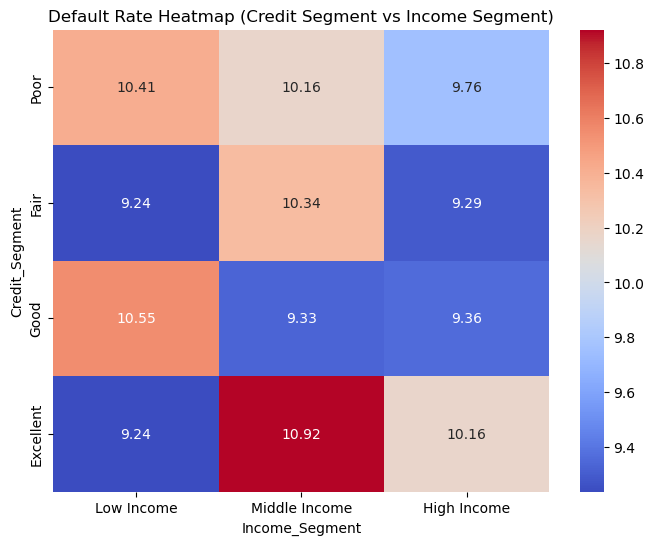

In [364]:
#Analysing high risk customer segments by credit score and income
loans["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

df = loans.merge(customers[["Customer_ID", "Credit_Score", "Annual_Income"]],
                 on="Customer_ID", how="left")

df["Credit_Segment"] = pd.cut(df["Credit_Score"],
                              bins=[300, 550, 650, 750, 900],
                              labels=["Poor", "Fair", "Good", "Excellent"])

df["Income_Segment"] = pd.qcut(df["Annual_Income"], q=3,
                               labels=["Low Income", "Middle Income", "High Income"])

df = df.merge(defaults[["Loan_ID", "Default_Amount"]],
              on="Loan_ID", how="left")

df["Default_Amount"] = df["Default_Amount"].fillna(0)

segment_risk = df.groupby(["Credit_Segment", "Income_Segment"]).agg(
    Total_Loans=("Loan_ID", "count"),
    Defaulted_Loans=("Default_Flag", "sum"),
    Default_Rate=("Default_Flag", "mean"),
    Avg_Default_Amount=("Default_Amount", "mean"),
    Total_Default_Amount=("Default_Amount", "sum")
).reset_index()

segment_risk["Default_Rate"] = segment_risk["Default_Rate"] * 100

segment_risk = segment_risk.sort_values(by="Default_Rate", ascending=False)

print("\n========== HIGH RISK CUSTOMER SEGMENTS (CREDIT + INCOME) ==========")
print(segment_risk)
print("===============================================================\n")

pivot_default_rate = segment_risk.pivot(index="Credit_Segment",
                                        columns="Income_Segment",
                                        values="Default_Rate")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_default_rate, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Default Rate Heatmap (Credit Segment vs Income Segment)")
plt.show()

## Analysis Tasks 19 : Time to Default Analysis

1. calculate the average time from loan disbursement to default for overdue loans.
2. Identify loan purposes with the shortest time to default
3. Compare the time to default across customer demographics

In [370]:
#Calculate the average time from loan disbursement to default for overdue loans
loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"], errors="coerce")
defaults["Default_Date"] = pd.to_datetime(defaults["Default_Date"], errors="coerce")

loans = loans.dropna(subset=["Disbursal_Date"])
defaults = defaults.dropna(subset=["Default_Date"])

df = defaults.merge(loans[["Loan_ID", "Disbursal_Date"]],
                    on="Loan_ID", how="left")

df = df.dropna(subset=["Disbursal_Date"])

df["Time_To_Default_Days"] = (df["Default_Date"] - df["Disbursal_Date"]).dt.days

df = df[df["Time_To_Default_Days"] >= 0]

avg_time_to_default = df["Time_To_Default_Days"].mean()

print("\n========== TIME TO DEFAULT ANALYSIS ==========")
print("Average Time from Disbursement to Default (Days):", round(avg_time_to_default, 2))
print("==============================================\n")

branch_time_default = df.groupby("Loan_ID")["Time_To_Default_Days"].mean().reset_index()
branch_time_default = branch_time_default.sort_values(by="Time_To_Default_Days", ascending=False)

print("\n========== BRANCH-WISE AVG TIME TO DEFAULT ==========")
print(branch_time_default.head(10))
print("====================================================\n")


========== TIME TO DEFAULT ANALYSIS ==========
Average Time from Disbursement to Default (Days): 630.7


========== BRANCH-WISE AVG TIME TO DEFAULT ==========
      Loan_ID  Time_To_Default_Days
305   L005362                1804.0
5291  L089229                1783.0
4405  L073838                1777.0
1692  L028536                1774.0
1588  L026778                1768.0
1944  L032939                1762.0
5229  L088131                1760.0
2223  L037297                1759.0
3622  L060855                1752.0
4822  L081283                1749.0



In [372]:
# Identify loan purposes with the shortest time to default
loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"], errors="coerce")
defaults["Default_Date"] = pd.to_datetime(defaults["Default_Date"], errors="coerce")

loans = loans.dropna(subset=["Disbursal_Date"])
defaults = defaults.dropna(subset=["Default_Date"])

df = defaults.merge(loans[["Loan_ID", "Disbursal_Date", "Loan_Purpose"]],
                    on="Loan_ID", how="left")

df = df.dropna(subset=["Disbursal_Date", "Loan_Purpose"])

df["Time_To_Default_Days"] = (df["Default_Date"] - df["Disbursal_Date"]).dt.days

df = df[df["Time_To_Default_Days"] >= 0]

purpose_time_default = df.groupby("Loan_Purpose").agg(
    Total_Default_Cases=("Loan_ID", "count"),
    Avg_Time_To_Default_Days=("Time_To_Default_Days", "mean"),
    Min_Time_To_Default_Days=("Time_To_Default_Days", "min"),
    Max_Time_To_Default_Days=("Time_To_Default_Days", "max")
).reset_index()

purpose_time_default = purpose_time_default.sort_values(by="Avg_Time_To_Default_Days", ascending=True)

print("\n========== LOAN PURPOSES WITH SHORTEST TIME TO DEFAULT ==========")
print(purpose_time_default.head(10))
print("===============================================================\n")


KeyError: "['Loan_Purpose'] not in index"

In [384]:
#Comparing the time to default across customer demographics
loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"], errors="coerce")
defaults["Default_Date"] = pd.to_datetime(defaults["Default_Date"], errors="coerce")

loans = loans.dropna(subset=["Disbursal_Date"])
defaults = defaults.dropna(subset=["Default_Date"])

df = defaults.merge(loans[["Loan_ID", "Customer_ID", "Disbursal_Date"]],
                    on="Loan_ID", how="left")

df = loans.merge(customers[["Customer_ID", "Employment_Status", "Annual_Income", "Credit_Score"]],
              on="Customer_ID", how="left")

# Remove missing customer details
df = df.dropna(subset=["Employment_Status", "Annual_Income", "Credit_Score"])

df["Time_To_Default_Days"] = (df["Default_Date"] - df["Disbursal_Date"]).dt.days

df = df[df["Time_To_Default_Days"] >= 0]

df["Income_Segment"] = pd.qcut(df["Annual_Income"], q=3,
                               labels=["Low Income", "Middle Income", "High Income"])

df["Credit_Segment"] = pd.cut(df["Credit_Score"],
                              bins=[300, 550, 650, 750, 900],
                              labels=["Poor", "Fair", "Good", "Excellent"])

emp_default_time = df.groupby("Employment_Status")["Time_To_Default_Days"].mean().reset_index()
emp_default_time = emp_default_time.sort_values(by="Time_To_Default_Days")

print("\n========== AVG TIME TO DEFAULT BY EMPLOYMENT STATUS ==========")
print(emp_default_time)
print("=============================================================\n")

plt.figure(figsize=(10,5))
sns.barplot(x="Employment_Status", y="Time_To_Default_Days", data=emp_default_time)
plt.title("Average Time to Default by Employment Status")
plt.xticks(rotation=45)
plt.ylabel("Avg Time to Default (Days)")
plt.show()

income_default_time = df.groupby("Income_Segment")["Time_To_Default_Days"].mean().reset_index()

print("\n========== AVG TIME TO DEFAULT BY INCOME SEGMENT ==========")
print(income_default_time)
print("==========================================================\n")

plt.figure(figsize=(8,5))
sns.barplot(x="Income_Segment", y="Time_To_Default_Days", data=income_default_time)
plt.title("Average Time to Default by Income Segment")
plt.ylabel("Avg Time to Default (Days)")
plt.show()

credit_default_time = df.groupby("Credit_Segment")["Time_To_Default_Days"].mean().reset_index()

print("\n========== AVG TIME TO DEFAULT BY CREDIT SCORE SEGMENT ==========")
print(credit_default_time)
print("===============================================================\n")

plt.figure(figsize=(8,5))
sns.barplot(x="Credit_Segment", y="Time_To_Default_Days", data=credit_default_time)
plt.title("Average Time to Default by Credit Score Segment")
plt.ylabel("Avg Time to Default (Days)")
plt.show()

KeyError: 'Default_Date'

## Analysis Tasks 20 : Transaction Pattern Analysis

1. Identify customers with irregular repayment patterns
2. Analyze penalty payments as a proportion of total transactions
3. Compare transaction amounts for overdue vs. non-overdue loans

In [387]:
#Identify customers with irregular repayment patterns
transactions["Transaction_Date"] = pd.to_datetime(transactions["Transaction_Date"], errors="coerce")
transactions = transactions.dropna(subset=["Transaction_Date"])

emi_txn = transactions[transactions["Payment_Type"].str.contains("EMI", case=False, na=False)]

emi_txn = emi_txn.merge(loans[["Loan_ID", "Customer_ID"]], on="Loan_ID", how="left")

emi_txn = emi_txn.sort_values(by=["Customer_ID", "Transaction_Date"])
NTS (DAYS)

emi_txn["Prev_Payment_Date"] = emi_txn.groupby("Customer_ID")["Transaction_Date"].shift(1)
emi_txn["Gap_Days"] = (emi_txn["Transaction_Date"] - emi_txn["Prev_Payment_Date"]).dt.days

emi_pattern = emi_txn.groupby("Customer_ID").agg(
    Total_EMI_Payments=("Transaction_ID", "count"),
    Avg_EMI_Amount=("Amount", "mean"),
    EMI_Std_Dev=("Amount", "std"),
    Avg_Gap_Days=("Gap_Days", "mean"),
    Max_Gap_Days=("Gap_Days", "max")
).reset_index()

emi_pattern["EMI_Std_Dev"] = emi_pattern["EMI_Std_Dev"].fillna(0)

penalty_txn = transactions[transactions["Payment_Type"].str.contains("Penalty", case=False, na=False)]
penalty_txn = penalty_txn.merge(loans[["Loan_ID", "Customer_ID"]], on="Loan_ID", how="left")

penalty_count = penalty_txn.groupby("Customer_ID").size().reset_index(name="Penalty_Count")

irregular_df = emi_pattern.merge(penalty_count, on="Customer_ID", how="left")
irregular_df["Penalty_Count"] = irregular_df["Penalty_Count"].fillna(0)

irregular_df["Irregularity_Score"] = (
    (irregular_df["EMI_Std_Dev"] / (irregular_df["Avg_EMI_Amount"] + 1)) +
    (irregular_df["Max_Gap_Days"] / 30) +
    (irregular_df["Penalty_Count"] / 5)
)

threshold = irregular_df["Irregularity_Score"].quantile(0.75)

irregular_df["Repayment_Pattern"] = np.where(
    irregular_df["Irregularity_Score"] >= threshold,
    "Irregular Repayer",
    "Regular Repayer"
)

irregular_df = irregular_df.sort_values(by="Irregularity_Score", ascending=False)

print("\n========== TOP 20 IRREGULAR REPAYMENT CUSTOMERS ==========")
print(irregular_df.head(20))
print("=========================================================\n")

print("Irregularity Threshold Used:", round(threshold, 2))


KeyError: 'Customer_ID'


========== PENALTY TRANSACTION PROPORTION ==========
Total Transactions Count : 495000
Penalty Transactions Count: 247844
Penalty Count Proportion  : 50.07%
----------------------------------------------------
Total Transaction Amount  : 12620730053
Penalty Transaction Amount: 6318173036
Penalty Amount Proportion : 50.06%



C:\Users\RICHA DESAI\AppData\Local\Temp\ipykernel_28944\4161963389.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penalty_txn["Transaction_Date"] = pd.to_datetime(penalty_txn["Transaction_Date"], errors="coerce")



========== MONTHLY PENALTY PROPORTION REPORT ==========
      Month  Total_Transactions  Total_Amount  Penalty_Transactions  \
0   2019-12                1050      26268671                   532   
1   2020-01                8465     216224851                  4200   
2   2020-02                8047     207940499                  4067   
3   2020-03                8432     214787946                  4217   
4   2020-04                8049     203970912                  3986   
5   2020-05                8349     213221356                  4230   
6   2020-06                8015     204970147                  4025   
7   2020-07                8454     215244984                  4255   
8   2020-08                8351     212404038                  4226   
9   2020-09                8112     208108567                  4054   
10  2020-10                8506     217455352                  4214   
11  2020-11                8011     203034811                  3961   

    Penalty_Amount 

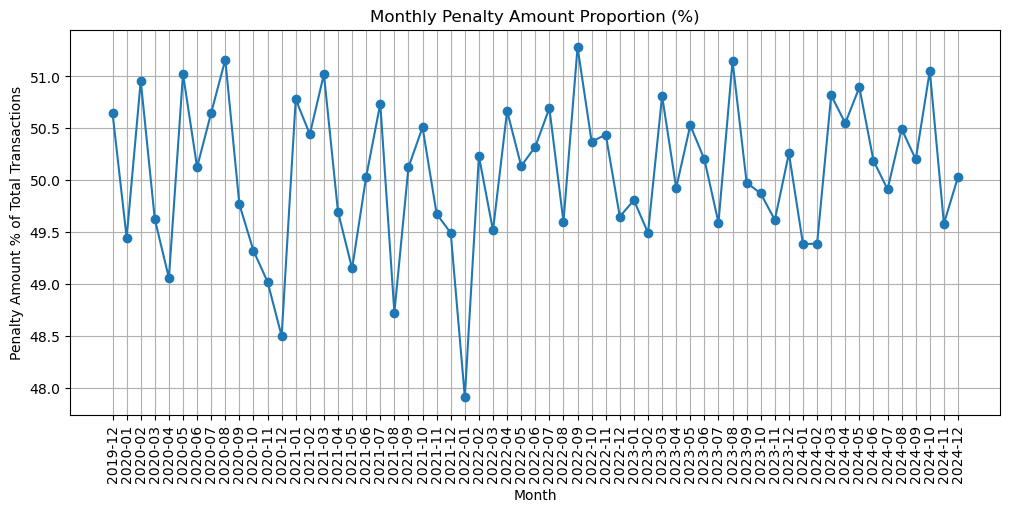

In [391]:
#Analyzing penalty payments as a proportion of total transactions

transactions["Payment_Type"] = transactions["Payment_Type"].astype(str).str.strip().str.title()

total_txn_count = transactions.shape[0]
total_txn_amount = transactions["Amount"].sum()

penalty_txn = transactions[transactions["Payment_Type"].str.contains("Penalty", case=False, na=False)]

penalty_count = penalty_txn.shape[0]
penalty_amount = penalty_txn["Amount"].sum()

penalty_count_pct = (penalty_count / total_txn_count) * 100
penalty_amount_pct = (penalty_amount / total_txn_amount) * 100

print("\n========== PENALTY TRANSACTION PROPORTION ==========")
print("Total Transactions Count :", total_txn_count)
print("Penalty Transactions Count:", penalty_count)
print(f"Penalty Count Proportion  : {penalty_count_pct:.2f}%")
print("----------------------------------------------------")
print("Total Transaction Amount  :", round(total_txn_amount, 2))
print("Penalty Transaction Amount:", round(penalty_amount, 2))
print(f"Penalty Amount Proportion : {penalty_amount_pct:.2f}%")
print("====================================================\n")

if "Transaction_Date" in transactions.columns:
    transactions["Transaction_Date"] = pd.to_datetime(transactions["Transaction_Date"], errors="coerce")
    transactions = transactions.dropna(subset=["Transaction_Date"])

    transactions["Month"] = transactions["Transaction_Date"].dt.to_period("M")

    monthly_total = transactions.groupby("Month").agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum")
    ).reset_index()

    penalty_txn["Transaction_Date"] = pd.to_datetime(penalty_txn["Transaction_Date"], errors="coerce")
    penalty_txn = penalty_txn.dropna(subset=["Transaction_Date"])
    penalty_txn["Month"] = penalty_txn["Transaction_Date"].dt.to_period("M")

    monthly_penalty = penalty_txn.groupby("Month").agg(
        Penalty_Transactions=("Transaction_ID", "count"),
        Penalty_Amount=("Amount", "sum")
    ).reset_index()

    monthly_report = monthly_total.merge(monthly_penalty, on="Month", how="left").fillna(0)

    monthly_report["Penalty_Count_Proportion"] = (monthly_report["Penalty_Transactions"] /
                                                  monthly_report["Total_Transactions"]) * 100

    monthly_report["Penalty_Amount_Proportion"] = (monthly_report["Penalty_Amount"] /
                                                   monthly_report["Total_Amount"]) * 100

    monthly_report["Month"] = monthly_report["Month"].astype(str)

    print("\n========== MONTHLY PENALTY PROPORTION REPORT ==========")
    print(monthly_report.head(12))
    print("======================================================\n")

    # Plot monthly penalty amount proportion
    plt.figure(figsize=(12,5))
    plt.plot(monthly_report["Month"], monthly_report["Penalty_Amount_Proportion"], marker="o")
    plt.title("Monthly Penalty Amount Proportion (%)")
    plt.xlabel("Month")
    plt.ylabel("Penalty Amount % of Total Transactions")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.show()


========== TRANSACTION AMOUNT SUMMARY (OVERDUE vs NON-OVERDUE) ==========
                         count          mean           std     min       25%  \
Loan_Status_Category                                                           
Non-Overdue Loan       15754.0  25539.017139  14162.813571  1000.0  13306.25   
Overdue Loan          479246.0  25495.024219  14143.422775  1000.0  13279.00   

                          50%      75%      max  
Loan_Status_Category                             
Non-Overdue Loan      25411.0  37736.0  49999.0  
Overdue Loan          25490.0  37729.0  50000.0  


========== AVERAGE TRANSACTION AMOUNT ==========
  Loan_Status_Category        Amount
0     Non-Overdue Loan  25539.017139
1         Overdue Loan  25495.024219



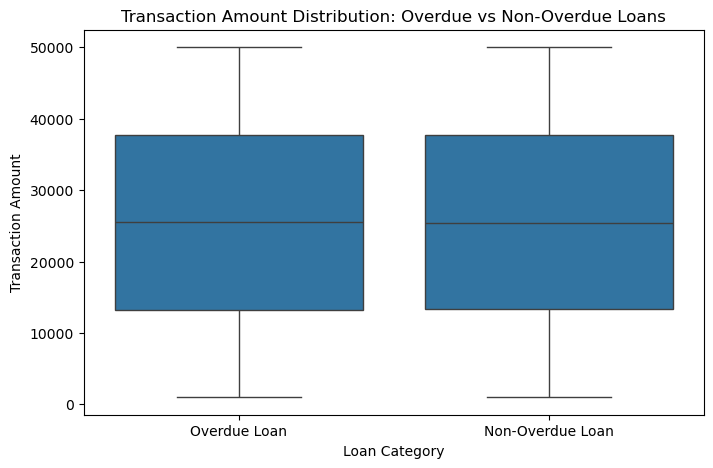

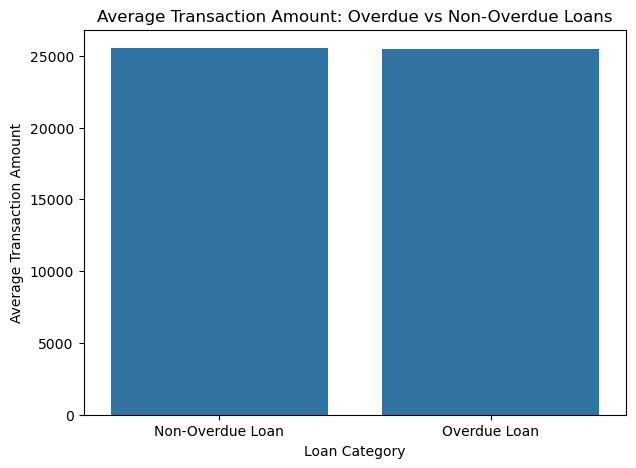

In [393]:
# Comparing transaction amounts for overdue vs. non overdue loans
transactions["Payment_Type"] = transactions["Payment_Type"].astype(str).str.strip().str.title()

overdue_loans = transactions[
    transactions["Payment_Type"].str.contains("Penalty|Overdue", case=False, na=False)
]["Loan_ID"].unique()

# Create Overdue Flag
transactions["Overdue_Flag"] = transactions["Loan_ID"].isin(overdue_loans).astype(int)

transactions["Loan_Status_Category"] = transactions["Overdue_Flag"].map({
    1: "Overdue Loan",
    0: "Non-Overdue Loan"
})

summary = transactions.groupby("Loan_Status_Category")["Amount"].describe()

print("\n========== TRANSACTION AMOUNT SUMMARY (OVERDUE vs NON-OVERDUE) ==========")
print(summary)
print("=========================================================================\n")


avg_amount = transactions.groupby("Loan_Status_Category")["Amount"].mean().reset_index()

print("\n========== AVERAGE TRANSACTION AMOUNT ==========")
print(avg_amount)
print("================================================\n")

plt.figure(figsize=(8,5))
sns.boxplot(x="Loan_Status_Category", y="Amount", data=transactions)
plt.title("Transaction Amount Distribution: Overdue vs Non-Overdue Loans")
plt.xlabel("Loan Category")
plt.ylabel("Transaction Amount")
plt.show()


plt.figure(figsize=(7,5))
sns.barplot(x="Loan_Status_Category", y="Amount", data=avg_amount)
plt.title("Average Transaction Amount: Overdue vs Non-Overdue Loans")
plt.xlabel("Loan Category")
plt.ylabel("Average Transaction Amount")
plt.show()
